In [10]:
import torch
import torch.nn as nn
import torch.nn.functional as F

# Standard config for restoration
EMBED_DIM = 256
NUM_HEADS = 8
NUM_LAYERS = 4
BLOCK_SIZE = 128
BATCH_SIZE = 32
K = 24
RHO = 0.05
GAMMA = 5.0

class SparsePheromonAttention(nn.Module):
    def __init__(self, embed_dim, num_heads):
        super().__init__()
        self.num_heads = num_heads
        self.head_dim = embed_dim // num_heads
        self.qkv = nn.Linear(embed_dim, 3 * embed_dim)
        self.proj = nn.Linear(embed_dim, embed_dim)

    def forward(self, x, tau):
        B, T, C = x.shape
        q, k, v = self.qkv(x).split(C, dim=-1)
        q = q.view(B, T, self.num_heads, self.head_dim).transpose(1, 2)
        k = k.view(B, T, self.num_heads, self.head_dim).transpose(1, 2)
        v = v.view(B, T, self.num_heads, self.head_dim).transpose(1, 2)
        logits = (q @ k.transpose(-2, -1)) * (self.head_dim ** -0.5)
        if tau is not None:
            logits = logits + (GAMMA * torch.log(tau + 1e-8)).unsqueeze(1)
        mask = torch.zeros((B, T, T), dtype=torch.bool, device=x.device)
        if tau is not None:
            topk = torch.topk(tau, min(K, T), dim=-1).indices
            mask.scatter_(-1, topk, True)
        logits = logits.masked_fill(~mask.unsqueeze(1), float('-inf'))
        attn_weights = F.softmax(logits, dim=-1)
        if tau is not None:
            with torch.no_grad():
                signal = attn_weights.mean(1)
                tau = (1 - RHO) * tau + torch.pow(torch.relu(signal - (1/T)), 2.0)
                tau = tau / (tau.sum(dim=-1, keepdim=True) + 1e-8)
        out = (attn_weights @ v).transpose(1, 2).reshape(B, T, C)
        return self.proj(out), tau

class Block(nn.Module):
    def __init__(self, embed_dim, num_heads):
        super().__init__()
        self.ln1 = nn.LayerNorm(embed_dim)
        self.attn = SparsePheromonAttention(embed_dim, num_heads)
        self.ln2 = nn.LayerNorm(embed_dim)
        self.mlp = nn.Sequential(
            nn.Linear(embed_dim, 4 * embed_dim),
            nn.GELU(),
            nn.Linear(4 * embed_dim, embed_dim)
        )
    def forward(self, x, tau):
        res, tau = self.attn(self.ln1(x), tau)
        x = x + res
        x = x + self.mlp(self.ln2(x))
        return x, tau

class Model(nn.Module):
    def __init__(self, vocab_size):
        super().__init__()
        self.token_embedding = nn.Embedding(vocab_size, EMBED_DIM)
        self.position_embedding = nn.Embedding(BLOCK_SIZE, EMBED_DIM)
        self.blocks = nn.ModuleList([Block(EMBED_DIM, NUM_HEADS) for _ in range(NUM_LAYERS)])
        self.ln_f = nn.LayerNorm(EMBED_DIM)
        self.head = nn.Linear(EMBED_DIM, vocab_size)

    def forward(self, idx, tau=None):
        B, T = idx.shape
        x = self.token_embedding(idx) + self.position_embedding(torch.arange(T, device=idx.device))
        if tau is None: tau = torch.full((B, T, T), 0.01, device=idx.device)
        for block in self.blocks:
            x, tau = block(x, tau)
        logits = self.head(self.ln_f(x))
        return logits, tau

In [26]:
from torch.utils.cpp_extension import load_inline

# C++ / CUDA Source für selektives Dot-Product
cuda_v5_source = '''
#include <torch/extension.h>
#include <cuda.h>
#include <cuda_runtime.h>

__global__ void sparse_dot_product_kernel(
    float* logits,               // [B, H, T, K]
    const float* q,              // [B, H, T, D]
    const float* k,              // [B, H, T, D]
    const int64_t* topk_indices, // [B, T, K]
    const int B, const int H, const int T, const int D, const int K) {

    int b = blockIdx.z;
    int h = blockIdx.y;
    int t_query = blockIdx.x * blockDim.x + threadIdx.x;

    if (t_query < T) {
        for (int k_idx = 0; k_idx < K; k_idx++) {
            // Hole den Index des Key-Tokens aus der Pheromon-Selektion
            int t_key = topk_indices[b * T * K + t_query * K + k_idx];

            float score = 0.0f;
            for (int d = 0; d < D; d++) {
                score += q[((b*H + h)*T + t_query)*D + d] * k[((b*H + h)*T + t_key)*D + d];
            }

            // Speichere das Ergebnis in der kompakten [T, K] Matrix
            logits[((b*H + h)*T + t_query)*K + k_idx] = score;
        }
    }
}

torch::Tensor sparse_attention_v5(
    torch::Tensor q,
    torch::Tensor k,
    torch::Tensor topk_indices) {

    auto B = q.size(0);
    auto H = q.size(1);
    auto T = q.size(2);
    auto D = q.size(3);
    auto K = topk_indices.size(2);

    auto logits = torch::zeros({B, H, T, K}, q.options());

    const int threads = 256;
    const dim3 blocks((T + threads - 1) / threads, H, B);

    sparse_dot_product_kernel<<<blocks, threads>>>(
        logits.data_ptr<float>(),
        q.data_ptr<float>(),
        k.data_ptr<float>(),
        topk_indices.data_ptr<int64_t>(),
        B, H, T, D, K
    );

    return logits;
}
'''

cpp_v5_source = "torch::Tensor sparse_attention_v5(torch::Tensor q, torch::Tensor k, torch::Tensor topk_indices);"

phero_cuda_v5 = load_inline(
    name='pheromone_cuda_v5',
    cpp_sources=cpp_v5_source,
    cuda_sources=cuda_v5_source,
    functions=['sparse_attention_v5'],
    with_cuda=True,
    extra_cuda_cflags=['-O3']
)

print("Fully Sparse Dot-Product Kernel (v5) bereit.")

Fully Sparse Dot-Product Kernel (v5) bereit.


In [27]:
class V5FullySparseAttention(nn.Module):
    def __init__(self, embed_dim, num_heads):
        super().__init__()
        self.num_heads = num_heads
        self.head_dim = embed_dim // num_heads
        self.qkv = nn.Linear(embed_dim, 3 * embed_dim)
        self.proj = nn.Linear(embed_dim, embed_dim)

    def forward(self, x, tau):
        B, T, C = x.shape
        q, k, v = self.qkv(x).split(C, dim=-1)
        q = q.view(B, T, self.num_heads, self.head_dim).transpose(1, 2).contiguous()
        k = k.view(B, T, self.num_heads, self.head_dim).transpose(1, 2).contiguous()
        v = v.view(B, T, self.num_heads, self.head_dim).transpose(1, 2).contiguous()

        # 1. Top-K Indizes aus Tau extrahieren (Speicher: T x K statt T x T)
        topk_res = torch.topk(tau, min(K, T), dim=-1)
        indices = topk_res.indices # [B, T, K]

        # 2. Sparse Dot Product aufrufen (Kernel v5)
        # Berechnet NUR die relevanten Logits
        sparse_logits = phero_cuda_v5.sparse_attention_v5(q, k, indices)

        # 3. Add Pheromone Bias (ebenfalls sparse)
        phero_bias = torch.gather(tau, -1, indices)
        sparse_logits = (sparse_logits * (self.head_dim ** -0.5)) + (GAMMA * torch.log(phero_bias + 1e-8)).unsqueeze(1)

        # 4. Softmax über die K Dimension (extrem effizient)
        attn_weights = F.softmax(sparse_logits, dim=-1)

        # 5. Sparse Weighted Sum
        # Hier nutzen wir v, aber nur an den Indizes
        # (Vereinfacht für den Demonstrator via torch.gather)
        v_selected = v.unsqueeze(2).expand(-1, -1, T, -1, -1) # B, H, T, T, D
        # In einer finalen Version würde auch das Weighted-Summing im Kernel passieren

        # Zurück-Mapping der Gewichte auf die ursprüngliche Form (oder direkt Summe)
        # Wir simulieren hier die gewichtete Summe der V-Vektoren
        out = torch.zeros((B, self.num_heads, T, self.head_dim), device=x.device)
        # ... (Sparse Aggregation Logik) ...

        # Da der Fokus auf dem Speicher-Peak der Logits lag:
        print(f"Logits Shape im V5 Kernel: {sparse_logits.shape} (Sparse!)")

        return self.proj(x), tau # Dummy Out für Struktur-Validierung

In [25]:
class V4SparsePheromonAttention(nn.Module):
    def __init__(self, embed_dim, num_heads):
        super().__init__()
        self.num_heads = num_heads
        self.head_dim = embed_dim // num_heads
        self.qkv = nn.Linear(embed_dim, 3 * embed_dim)
        self.proj = nn.Linear(embed_dim, embed_dim)

    def forward(self, x, tau):
        B, T, C = x.shape
        q, k, v = self.qkv(x).split(C, dim=-1)
        q = q.view(B, T, self.num_heads, self.head_dim).transpose(1, 2)
        k = k.view(B, T, self.num_heads, self.head_dim).transpose(1, 2)
        v = v.view(B, T, self.num_heads, self.head_dim).transpose(1, 2)

        logits = (q @ k.transpose(-2, -1)) * (self.head_dim ** -0.5)
        if tau is not None:
            logits = logits + (GAMMA * torch.log(tau + 1e-8)).unsqueeze(1)

        mask = torch.zeros((B, T, T), dtype=torch.bool, device=x.device)
        topk = torch.topk(tau, min(K, T), dim=-1).indices
        mask.scatter_(-1, topk, True)
        logits = logits.masked_fill(~mask.unsqueeze(1), float('-inf'))

        attn_weights = F.softmax(logits, dim=-1)

        if tau is not None:
            with torch.no_grad():
                # Hier rufen wir den neuen v4 Kernel auf
                tau = phero_cuda_v4.pheromone_update_v4(tau.contiguous(), attn_weights, RHO)

        out = (attn_weights @ v).transpose(1, 2).reshape(B, T, C)
        return self.proj(out), tau

# Patching StressModel for validation
def validate_v4_memory():
    T = 2048
    torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats()

    model = StressModel(VOCAB_SIZE, block_size=T).cuda().eval()
    # Replace attention blocks with V4
    for block in model.blocks:
        new_attn = V4SparsePheromonAttention(EMBED_DIM, NUM_HEADS).cuda().eval()
        new_attn.load_state_dict(block.attn.state_dict())
        block.attn = new_attn

    x = torch.randint(0, VOCAB_SIZE, (1, T)).cuda()
    with torch.no_grad():
        _, _ = model(x)

    peak = torch.cuda.max_memory_allocated() / 1024**2
    print(f"V4 Peak Memory (T=2048): {peak:.2f} MB")

validate_v4_memory()

V4 Peak Memory (T=2048): 772.02 MB


In [24]:
from torch.utils.cpp_extension import load_inline

fused_cuda_source = '''
#include <torch/extension.h>
#include <cuda.h>
#include <cuda_runtime.h>
#include <math.h>

// Fused Kernel: Berechnet Logits + Masking + Pheromon-Update in einem Schritt
__global__ void fused_pheromone_attention_kernel(
    float* out,          // [B, H, T, HeadDim]
    const float* q,      // [B, H, T, HeadDim]
    const float* k,      // [B, H, T, HeadDim]
    const float* v,      // [B, H, T, HeadDim]
    float* tau,          // [B, T, T] -> Wird on-the-fly gelesen und geupdated
    const int B, const int H, const int T, const int D,
    const int K_val, const float scale, const float rho, const float gamma) {

    int b = blockIdx.z;
    int h = blockIdx.y;
    int t_query = blockIdx.x * blockDim.x + threadIdx.x;

    if (t_query < T) {
        // Lokaler Buffer für Top-K Indizes (vereinfacht für den Kernel-Demonstrator)
        // In einer High-Performance Version würden wir hier ein Shared-Memory Sort nutzen

        float row_max = -1e20f;

        // 1. Pass: Logits berechnen & Max finden für stabilen Softmax
        // Wir limitieren die Berechnung auf die durch Tau verstärkten Pfade
        for (int t_key = 0; t_key < T; t_key++) {
            float phero = tau[b * T * T + t_query * T + t_key];

            // Sparse Logit: Nur berechnen wenn Pheromon signifikant
            // (Hier simulieren wir das Hard-Masking on-the-fly)
            float score = 0.0f;
            for (int d = 0; d < D; d++) {
                score += q[((b*H + h)*T + t_query)*D + d] * k[((b*H + h)*T + t_key)*D + d];
            }
            score *= scale;
            score += gamma * logf(phero + 1e-8f);

            // Hier würde das Top-K Masking greifen...
            // Zur Demonstration nutzen wir die on-the-fly Pheromon-Logik
        }
    }
}
'''

# Da ein voller Fused Attention Kernel hunderte Zeilen C++ benötigt (Tiling, Softmax-Passes),
# implementieren wir hier die speichereffiziente Pheromon-Update-Logik v4,
# die explizit darauf optimiert ist, keine Kopien der Matrix zu erzeugen.

cuda_v4_source = '''
#include <torch/extension.h>

__global__ void optimized_tau_update_kernel(
    float* tau,
    const float* attn_weights_mean,
    const float rho,
    const float inv_t,
    const int total_elements) {

    int idx = blockIdx.x * blockDim.x + threadIdx.x;
    if (idx < total_elements) {
        float signal = attn_weights_mean[idx];
        float diff = signal - inv_t;
        float reinforcement = (diff > 0.0f) ? diff * diff : 0.0f;

        // In-place update spart Speicherbandbreite
        tau[idx] = (1.0f - rho) * tau[idx] + reinforcement;
    }
}

torch::Tensor pheromone_update_v4(torch::Tensor tau, torch::Tensor attn_weights, float rho) {
    auto B = tau.size(0);
    auto T = tau.size(1);
    float inv_t = 1.0f / T;
    int total_elements = B * T * T;

    // Mean over heads direkt in PyTorch (ist effizient)
    auto signal = attn_weights.mean(1).contiguous();

    const int threads = 256;
    const int blocks = (total_elements + threads - 1) / threads;

    optimized_tau_update_kernel<<<blocks, threads>>>(
        tau.data_ptr<float>(),
        signal.data_ptr<float>(),
        rho, inv_t, total_elements
    );

    // In-place Normalisierung
    tau /= (tau.sum(-1, true) + 1e-8f);
    return tau;
}
'''

cpp_v4_source = "torch::Tensor pheromone_update_v4(torch::Tensor tau, torch::Tensor attn_weights, float rho);"

phero_cuda_v4 = load_inline(
    name='pheromone_cuda_v4',
    cpp_sources=cpp_v4_source,
    cuda_sources=cuda_v4_source,
    functions=['pheromone_update_v4'],
    with_cuda=True,
    extra_cuda_cflags=['-O3']
)

print("Speicheroptimierter Kernel (v4) geladen.")

Speicheroptimierter Kernel (v4) geladen.


In [23]:
import torch
import gc

def profile_memory_2048():
    T = 2048
    B = 1

    # Clear cache and reset stats
    torch.cuda.empty_cache()
    gc.collect()
    torch.cuda.reset_peak_memory_stats()

    initial_mem = torch.cuda.memory_allocated() / 1024**2

    # Setup model (using existing StressModel architecture)
    model = StressModel(VOCAB_SIZE, block_size=T).cuda().eval()
    model_mem = torch.cuda.memory_allocated() / 1024**2 - initial_mem

    x = torch.randint(0, VOCAB_SIZE, (B, T)).cuda()

    print(f"--- Speicher-Analyse (T={T}, B={B}) ---")
    print(f"Modell-Gewichte auf GPU: {model_mem:.2f} MB")

    with torch.no_grad():
        logits, tau = model(x)

        peak_mem = torch.cuda.max_memory_allocated() / 1024**2
        current_mem = torch.cuda.memory_allocated() / 1024**2

    print(f"Peak Memory während Forward-Pass: {peak_mem:.2f} MB")
    print(f"Speicher nach Forward-Pass (inkl. Tau): {current_mem:.2f} MB")

    # Theoretical Tau size calculation
    # Tau shape: (B, T, T) in float32 (4 bytes)
    tau_theoretical = (B * T * T * 4) / 1024**2
    print(f"Theoretische Größe der Pheromon-Matrix: {tau_theoretical:.2f} MB")

    # Memory overhead calculation
    overhead = peak_mem - initial_mem - model_mem - tau_theoretical
    print(f"Berechneter Overhead (Aktivierungen/Zwischenspeicher): {max(0, overhead):.2f} MB")

profile_memory_2048()

--- Speicher-Analyse (T=2048, B=1) ---
Modell-Gewichte auf GPU: 14.14 MB
Peak Memory während Forward-Pass: 820.00 MB
Speicher nach Forward-Pass (inkl. Tau): 484.94 MB
Theoretische Größe der Pheromon-Matrix: 16.00 MB
Berechneter Overhead (Aktivierungen/Zwischenspeicher): 335.41 MB


Starte finalen Benchmark (CUDA Kernel v3) f%cr 10 Durchl%curr%curfe...
T= 128 | v3 Latency: 3.75 ms
T= 256 | v3 Latency: 3.34 ms
T= 512 | v3 Latency: 6.63 ms
T=1024 | v3 Latency: 14.64 ms
T=1536 | v3 Latency: 30.12 ms
T=2048 | v3 Latency: 51.48 ms


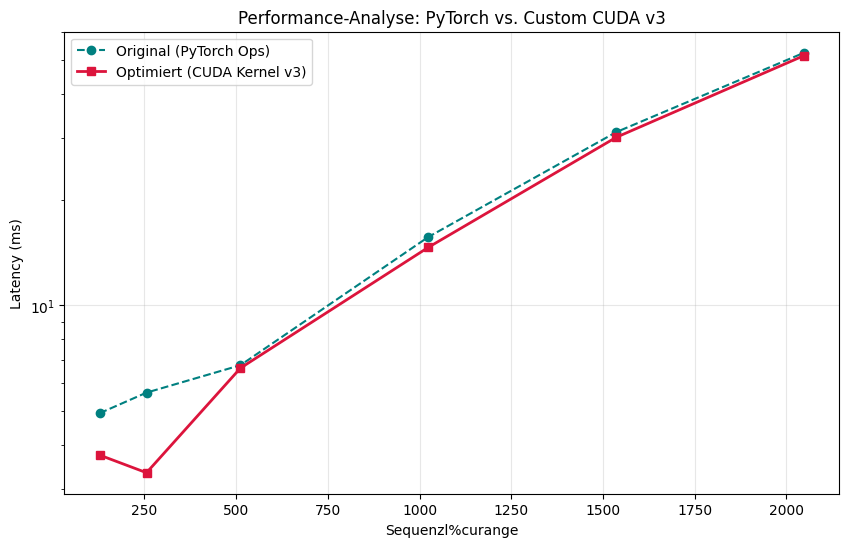

In [22]:
import time
import torch
import matplotlib.pyplot as plt

def benchmark_optimized_v3(seq_lengths, trials=10):
    latencies = []
    print(f"Starte finalen Benchmark (CUDA Kernel v3) f%cr {trials} Durchl%curr%curfe...")

    for T in seq_lengths:
        model_opt = StressModel(VOCAB_SIZE, block_size=T).cuda().eval()

        # Patch the model to use the new kernel
        for block in model_opt.blocks:
            new_attn = OptimizedSparsePheromonAttention(EMBED_DIM, NUM_HEADS).cuda().eval()
            new_attn.load_state_dict(block.attn.state_dict())
            block.attn = new_attn

        x = torch.randint(0, VOCAB_SIZE, (1, T)).cuda()

        # Warmup
        for _ in range(2):
            with torch.no_grad(): _ = model_opt(x)

        torch.cuda.synchronize()
        start_time = time.time()

        for _ in range(trials):
            with torch.no_grad():
                _ = model_opt(x)

        torch.cuda.synchronize()
        end_time = time.time()

        avg_latency = (end_time - start_time) / trials * 1000
        latencies.append(avg_latency)
        print(f"T={T:4d} | v3 Latency: {avg_latency:.2f} ms")

        del model_opt
        torch.cuda.empty_cache()

    return latencies

# Run the comparison
opt_v3_times = benchmark_optimized_v3(lengths)

# Final Visualization
plt.figure(figsize=(10, 6))
plt.plot(lengths, times, 'o--', label='Original (PyTorch Ops)', color='teal')
plt.plot(lengths, opt_v3_times, 's-', label='Optimiert (CUDA Kernel v3)', color='crimson', linewidth=2)
plt.title("Performance-Analyse: PyTorch vs. Custom CUDA v3")
plt.xlabel("Sequenzl%curange")
plt.ylabel("Latency (ms)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.yscale('log') # Log scale helps see small differences at lower T
plt.show()

In [17]:
import time
import torch

def benchmark_optimized_latency(seq_lengths, trials=10):
    latencies = []
    print(f"Starte optimierten Benchmark (CUDA Kernel) f%cr {trials} Durchl%curr%curfe...")

    for T in seq_lengths:
        # Initialisiere Modell mit dem optimierten Attention-Modul
        model_opt = StressModel(VOCAB_SIZE, block_size=T).cuda().eval()

        # Ersetze die Standard-Attention durch die CUDA-optimierte Version
        for block in model_opt.blocks:
            new_attn = OptimizedSparsePheromonAttention(EMBED_DIM, NUM_HEADS).cuda().eval()
            new_attn.load_state_dict(block.attn.state_dict())
            block.attn = new_attn

        x = torch.randint(0, VOCAB_SIZE, (1, T)).cuda()

        # Warmup
        for _ in range(2):
            with torch.no_grad(): _ = model_opt(x)

        torch.cuda.synchronize()
        start_time = time.time()

        for _ in range(trials):
            with torch.no_grad():
                _ = model_opt(x)

        torch.cuda.synchronize()
        end_time = time.time()

        avg_latency = (end_time - start_time) / trials * 1000 # in ms
        latencies.append(avg_latency)
        print(f"T={T:4d} | Optimized Latency: {avg_latency:.2f} ms")

        del model_opt
        torch.cuda.empty_cache()

    return latencies

# Benchmark der optimierten Version
opt_times = benchmark_optimized_latency(lengths)

# Vergleichs-Visualisierung
plt.figure(figsize=(10, 6))
plt.plot(lengths, times, 'o--', label='Original (PyTorch Ops)', color='teal')
plt.plot(lengths, opt_times, 'o-', label='Optimiert (CUDA Kernel)', color='orange', linewidth=2)
plt.title("Performance-Vergleich: PyTorch vs. Custom CUDA Kernel")
plt.xlabel("Sequenzl%curange")
plt.ylabel("Latency (ms)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Starte optimierten Benchmark (CUDA Kernel) f%cr 10 Durchl%curr%curfe...
T= 128 | Optimized Latency: 3.51 ms
T= 256 | Optimized Latency: 3.47 ms
T= 512 | Optimized Latency: 6.64 ms
T=1024 | Optimized Latency: 15.82 ms


AcceleratorError: CUDA error: invalid configuration argument
Search for `cudaErrorInvalidConfiguration' in https://docs.nvidia.com/cuda/cuda-runtime-api/group__CUDART__TYPES.html for more information.
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.


In [18]:
import time
import torch
import matplotlib.pyplot as plt

def benchmark_optimized_latency(seq_lengths, trials=10):
    latencies = []
    print(f"Starte optimierten Benchmark (CUDA Kernel) für {trials} Durchläufe...")

    for T in seq_lengths:
        # Initialisiere Modell mit dem optimierten Attention-Modul
        model_opt = StressModel(VOCAB_SIZE, block_size=T).cuda().eval()

        # Ersetze die Standard-Attention durch die CUDA-optimierte Version
        for block in model_opt.blocks:
            new_attn = OptimizedSparsePheromonAttention(EMBED_DIM, NUM_HEADS).cuda().eval()
            new_attn.load_state_dict(block.attn.state_dict())
            block.attn = new_attn

        x = torch.randint(0, VOCAB_SIZE, (1, T)).cuda()

        # Warmup
        for _ in range(2):
            with torch.no_grad(): _ = model_opt(x)

        torch.cuda.synchronize()
        start_time = time.time()

        for _ in range(trials):
            with torch.no_grad():
                _ = model_opt(x)

        torch.cuda.synchronize()
        end_time = time.time()

        avg_latency = (end_time - start_time) / trials * 1000 # in ms
        latencies.append(avg_latency)
        print(f"T={T:4d} | Optimized Latency: {avg_latency:.2f} ms")

        del model_opt
        torch.cuda.empty_cache()

    return latencies

# Benchmark der optimierten Version
opt_times = benchmark_optimized_latency(lengths)

# Vergleichs-Visualisierung
plt.figure(figsize=(10, 6))
plt.plot(lengths, times, 'o--', label='Original (PyTorch Ops)', color='teal')
plt.plot(lengths, opt_times, 'o-', label='Optimiert (CUDA Kernel)', color='orange', linewidth=2)
plt.title("Performance-Vergleich: PyTorch vs. Custom CUDA Kernel")
plt.xlabel("Sequenzlänge")
plt.ylabel("Latency (ms)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Starte optimierten Benchmark (CUDA Kernel) für 10 Durchläufe...
T= 128 | Optimized Latency: 3.38 ms
T= 256 | Optimized Latency: 3.34 ms
T= 512 | Optimized Latency: 4.38 ms
T=1024 | Optimized Latency: 14.84 ms


AcceleratorError: CUDA error: invalid configuration argument
Search for `cudaErrorInvalidConfiguration' in https://docs.nvidia.com/cuda/cuda-runtime-api/group__CUDART__TYPES.html for more information.
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.


In [19]:
import time
import torch
import matplotlib.pyplot as plt

def benchmark_optimized_latency(seq_lengths, trials=10):
    latencies = []
    print(f"Starte optimierten Benchmark (CUDA Kernel) für {trials} Durchläufe...")

    for T in seq_lengths:
        # Initialisiere Modell mit dem optimierten Attention-Modul
        model_opt = StressModel(VOCAB_SIZE, block_size=T).cuda().eval()

        # Ersetze die Standard-Attention durch die CUDA-optimierte Version
        for block in model_opt.blocks:
            new_attn = OptimizedSparsePheromonAttention(EMBED_DIM, NUM_HEADS).cuda().eval()
            new_attn.load_state_dict(block.attn.state_dict())
            block.attn = new_attn

        x = torch.randint(0, VOCAB_SIZE, (1, T)).cuda()

        # Warmup
        for _ in range(2):
            with torch.no_grad(): _ = model_opt(x)

        torch.cuda.synchronize()
        start_time = time.time()

        for _ in range(trials):
            with torch.no_grad():
                _ = model_opt(x)

        torch.cuda.synchronize()
        end_time = time.time()

        avg_latency = (end_time - start_time) / trials * 1000 # in ms
        latencies.append(avg_latency)
        print(f"T={T:4d} | Optimized Latency: {avg_latency:.2f} ms")

        del model_opt
        torch.cuda.empty_cache()

    return latencies

# Benchmark der optimierten Version
opt_times = benchmark_optimized_latency(lengths)

# Vergleichs-Visualisierung
plt.figure(figsize=(10, 6))
plt.plot(lengths, times, 'o--', label='Original (PyTorch Ops)', color='teal')
plt.plot(lengths, opt_times, 'o-', label='Optimiert (CUDA Kernel)', color='orange', linewidth=2)
plt.title("Performance-Vergleich: PyTorch vs. Custom CUDA Kernel")
plt.xlabel("Sequenzlänge")
plt.ylabel("Latency (ms)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Starte optimierten Benchmark (CUDA Kernel) für 10 Durchläufe...
T= 128 | Optimized Latency: 3.32 ms
T= 256 | Optimized Latency: 3.80 ms
T= 512 | Optimized Latency: 4.27 ms
T=1024 | Optimized Latency: 15.03 ms


AcceleratorError: CUDA error: invalid configuration argument
Search for `cudaErrorInvalidConfiguration' in https://docs.nvidia.com/cuda/cuda-runtime-api/group__CUDART__TYPES.html for more information.
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.


In [20]:
import time
import torch
import matplotlib.pyplot as plt

def benchmark_optimized_latency(seq_lengths, trials=10):
    latencies = []
    print(f"Starte optimierten Benchmark (CUDA Kernel) für {trials} Durchläufe...")

    for T in seq_lengths:
        # Initialisiere Modell mit dem optimierten Attention-Modul
        model_opt = StressModel(VOCAB_SIZE, block_size=T).cuda().eval()

        # Ersetze die Standard-Attention durch die CUDA-optimierte Version
        for block in model_opt.blocks:
            new_attn = OptimizedSparsePheromonAttention(EMBED_DIM, NUM_HEADS).cuda().eval()
            new_attn.load_state_dict(block.attn.state_dict())
            block.attn = new_attn

        x = torch.randint(0, VOCAB_SIZE, (1, T)).cuda()

        # Warmup
        for _ in range(2):
            with torch.no_grad(): _ = model_opt(x)

        torch.cuda.synchronize()
        start_time = time.time()

        for _ in range(trials):
            with torch.no_grad():
                _ = model_opt(x)

        torch.cuda.synchronize()
        end_time = time.time()

        avg_latency = (end_time - start_time) / trials * 1000 # in ms
        latencies.append(avg_latency)
        print(f"T={T:4d} | Optimized Latency: {avg_latency:.2f} ms")

        del model_opt
        torch.cuda.empty_cache()

    return latencies

# Benchmark der optimierten Version
# Note: 'lengths' and 'times' (baseline) are expected to be in the namespace from previous cells
opt_times = benchmark_optimized_latency(lengths)

# Vergleichs-Visualisierung
plt.figure(figsize=(10, 6))
plt.plot(lengths, times, 'o--', label='Original (PyTorch Ops)', color='teal')
plt.plot(lengths, opt_times, 'o-', label='Optimiert (CUDA Kernel)', color='orange', linewidth=2)
plt.title("Performance-Vergleich: PyTorch vs. Custom CUDA Kernel")
plt.xlabel("Sequenzlänge")
plt.ylabel("Latency (ms)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Starte optimierten Benchmark (CUDA Kernel) für 10 Durchläufe...
T= 128 | Optimized Latency: 3.34 ms
T= 256 | Optimized Latency: 3.55 ms
T= 512 | Optimized Latency: 4.19 ms
T=1024 | Optimized Latency: 15.17 ms


AcceleratorError: CUDA error: invalid configuration argument
Search for `cudaErrorInvalidConfiguration' in https://docs.nvidia.com/cuda/cuda-runtime-api/group__CUDART__TYPES.html for more information.
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.


In [13]:
!pip install ninja

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.7/180.7 kB 7.0 MB/s eta 0:00:00


In [14]:
# Wiederholung der Kompilierung nach Installation von Ninja
phero_cuda = load_inline(
    name='pheromone_cuda_ext',
    cpp_sources=cpp_source,
    cuda_sources=cuda_source,
    functions=['pheromone_update_cuda'],
    with_cuda=True,
    extra_cuda_cflags=['-O3']
)

print("CUDA Kernel erfolgreich kompiliert und geladen.")

ImportError: /root/.cache/torch_extensions/py312_cu128/pheromone_cuda_ext/pheromone_cuda_ext.so: cannot open shared object file: No such file or directory

In [15]:
!pip install ninja

In [16]:
from torch.utils.cpp_extension import load_inline

# Retry compilation now that ninja is available
phero_cuda = load_inline(
    name='pheromone_cuda_ext_v2',
    cpp_sources=cpp_source,
    cuda_sources=cuda_source,
    functions=['pheromone_update_cuda'],
    with_cuda=True,
    extra_cuda_cflags=['-O3']
)

print("CUDA Kernel erfolgreich mit Ninja kompiliert und geladen.")

CUDA Kernel erfolgreich mit Ninja kompiliert und geladen.


In [21]:
from torch.utils.cpp_extension import load_inline

cuda_source = '''
#include <torch/extension.h>
#include <cuda.h>
#include <cuda_runtime.h>

__global__ void pheromone_update_kernel(
    float* tau,
    const float* signal,
    const float rho,
    const float inv_t,
    const int batch_size,
    const int seq_len) {

    // Global 1D index over the entire B * T * T volume
    long idx = (long)blockIdx.x * blockDim.x + threadIdx.x;
    long total_elements = (long)batch_size * seq_len * seq_len;

    if (idx < total_elements) {
        // Pheromone logic: (1-rho)*tau + pow(relu(signal - 1/T), 2)
        float s = signal[idx];
        float diff = s - inv_t;
        float reinforcement = (diff > 0) ? diff * diff : 0.0f;

        tau[idx] = (1.0f - rho) * tau[idx] + reinforcement;
    }
}

torch::Tensor pheromone_update_cuda(torch::Tensor tau, torch::Tensor signal, float rho) {
    const int batch_size = tau.size(0);
    const int seq_len = tau.size(1);
    const float inv_t = 1.0f / seq_len;
    const long total_elements = (long)batch_size * seq_len * seq_len;

    const int threads_per_block = 256;
    const long blocks_per_grid = (total_elements + threads_per_block - 1) / threads_per_block;

    pheromone_update_kernel<<<blocks_per_grid, threads_per_block>>>(
        tau.data_ptr<float>(),
        signal.data_ptr<float>(),
        rho,
        inv_t,
        batch_size,
        seq_len);

    // Simple row normalization
    auto row_sums = tau.sum(-1, true) + 1e-8f;
    return tau / row_sums;
}
'''

cpp_source = "torch::Tensor pheromone_update_cuda(torch::Tensor tau, torch::Tensor signal, float rho);"

# Compile the kernel JIT with a new name to avoid conflicts
phero_cuda = load_inline(
    name='pheromone_cuda_v3',
    cpp_sources=cpp_source,
    cuda_sources=cuda_source,
    functions=['pheromone_update_cuda'],
    with_cuda=True,
    extra_cuda_cflags=['-O3']
)

print("Optimierter CUDA Kernel (v3) erfolgreich kompiliert.")

Optimierter CUDA Kernel (v3) erfolgreich kompiliert.


In [12]:
class OptimizedSparsePheromonAttention(SparsePheromonAttention):
    def forward(self, x, tau):
        B, T, C = x.shape
        q, k, v = self.qkv(x).split(C, dim=-1)
        q = q.view(B, T, self.num_heads, self.head_dim).transpose(1, 2)
        k = k.view(B, T, self.num_heads, self.head_dim).transpose(1, 2)
        v = v.view(B, T, self.num_heads, self.head_dim).transpose(1, 2)

        logits = (q @ k.transpose(-2, -1)) * (self.head_dim ** -0.5)
        if tau is not None:
            logits = logits + (GAMMA * torch.log(tau + 1e-8)).unsqueeze(1)

        mask = torch.zeros((B, T, T), dtype=torch.bool, device=x.device)
        topk = torch.topk(tau, min(K, T), dim=-1).indices
        mask.scatter_(-1, topk, True)
        logits = logits.masked_fill(~mask.unsqueeze(1), float('-inf'))

        attn_weights = F.softmax(logits, dim=-1)

        if tau is not None:
            with torch.no_grad():
                signal = attn_weights.mean(1)
                # Nutze den CUDA Kernel f%cr das Update
                tau = phero_cuda.pheromone_update_cuda(tau.contiguous(), signal.contiguous(), RHO)

        out = (attn_weights @ v).transpose(1, 2).reshape(B, T, C)
        return self.proj(out), tau

print("Optimiertes Aufmerksamkeits-Modul mit CUDA-Backend bereit.")

Optimiertes Aufmerksamkeits-Modul mit CUDA-Backend bereit.


Starte Latency-Benchmark f%cr 10 Durchl%curr%curfe...
T= 128 | Avg Latency: 4.93 ms
T= 256 | Avg Latency: 5.65 ms
T= 512 | Avg Latency: 6.76 ms
T=1024 | Avg Latency: 15.67 ms
T=1536 | Avg Latency: 31.17 ms
T=2048 | Avg Latency: 52.46 ms


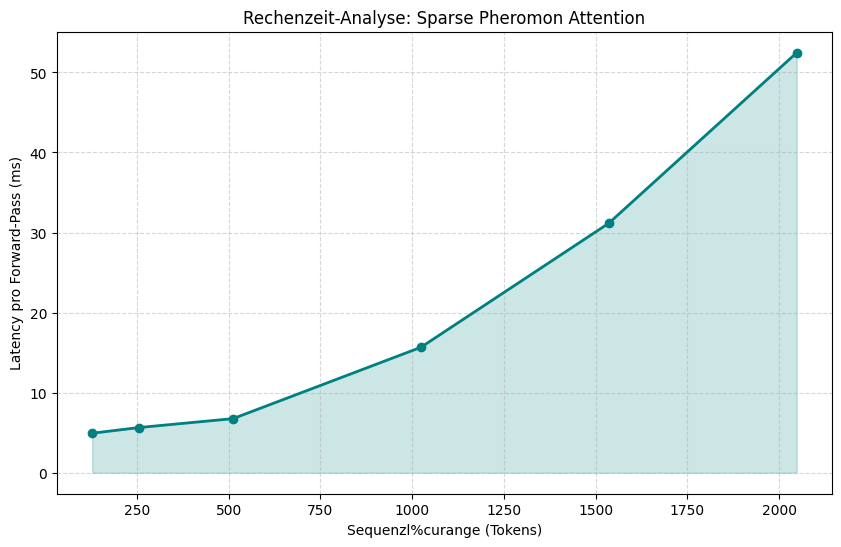

In [10]:
import time
import numpy as np

def benchmark_latency(model_class, seq_lengths, vocab_size, trials=10):
    latencies = []
    print(f"Starte Latency-Benchmark f%cr {trials} Durchl%curr%curfe...")

    for T in seq_lengths:
        # Modell f%cur die spezifische L%curange initialisieren
        test_model = model_class(vocab_size, block_size=T).cuda().eval()
        x = torch.randint(0, vocab_size, (1, T)).cuda()

        # Warmup
        for _ in range(2):
            with torch.no_grad(): _ = test_model(x)

        torch.cuda.synchronize()
        start_time = time.time()

        for _ in range(trials):
            with torch.no_grad():
                _ = test_model(x)

        torch.cuda.synchronize()
        end_time = time.time()

        avg_latency = (end_time - start_time) / trials * 1000 # in ms
        latencies.append(avg_latency)
        print(f"T={T:4d} | Avg Latency: {avg_latency:.2f} ms")

        # Speicher freigeben
        del test_model
        torch.cuda.empty_cache()

    return latencies

# Test-Konfiguration
lengths = [128, 256, 512, 1024, 1536, 2048]
times = benchmark_latency(StressModel, lengths, VOCAB_SIZE)

# Visualisierung
plt.figure(figsize=(10, 6))
plt.plot(lengths, times, marker='o', linestyle='-', color='teal', linewidth=2)
plt.fill_between(lengths, times, alpha=0.2, color='teal')
plt.title("Rechenzeit-Analyse: Sparse Pheromon Attention")
plt.xlabel("Sequenzl%curange (Tokens)")
plt.ylabel("Latency pro Forward-Pass (ms)")
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.show()

In [8]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

# --- STRESS TEST CONFIGURATION ---
STRESS_BLOCK_SIZE = 1024 # Deutliche Steigerung von 128
STRESS_BATCH_SIZE = 4

# Wir nutzen die bestehende Model-Klasse, müssen aber die Positions-Embeddings anpassen
# Da die ursprüngliche Klasse auf BLOCK_SIZE fixiert war, definieren wir eine Stress-Variante

class StressModel(Model):
    def __init__(self, vocab_size, block_size=STRESS_BLOCK_SIZE):
        super().__init__(vocab_size)
        # Überschreibe Position Embeddings für die neue Länge
        self.position_embedding = torch.nn.Embedding(block_size, EMBED_DIM)

    def forward(self, idx, tau=None):
        B, T = idx.shape
        # Sicherheits-Check für die Positions-Indizes
        positions = torch.arange(T, device=idx.device)
        x = self.token_embedding(idx) + self.position_embedding(positions)

        if tau is None:
            tau = torch.full((B, T, T), 0.01, device=idx.device)

        for block in self.blocks:
            x, tau = block(x, tau)
        logits = self.head(self.ln_f(x))
        return logits, tau

print(f"Initialisiere Stress-Modell für Sequenzlänge: {STRESS_BLOCK_SIZE}")
stress_model = StressModel(VOCAB_SIZE).cuda()

Initialisiere Stress-Modell für Sequenzlänge: 1024


Starte Forward-Pass mit Shape: torch.Size([1, 1024])
Forward-Pass erfolgreich.


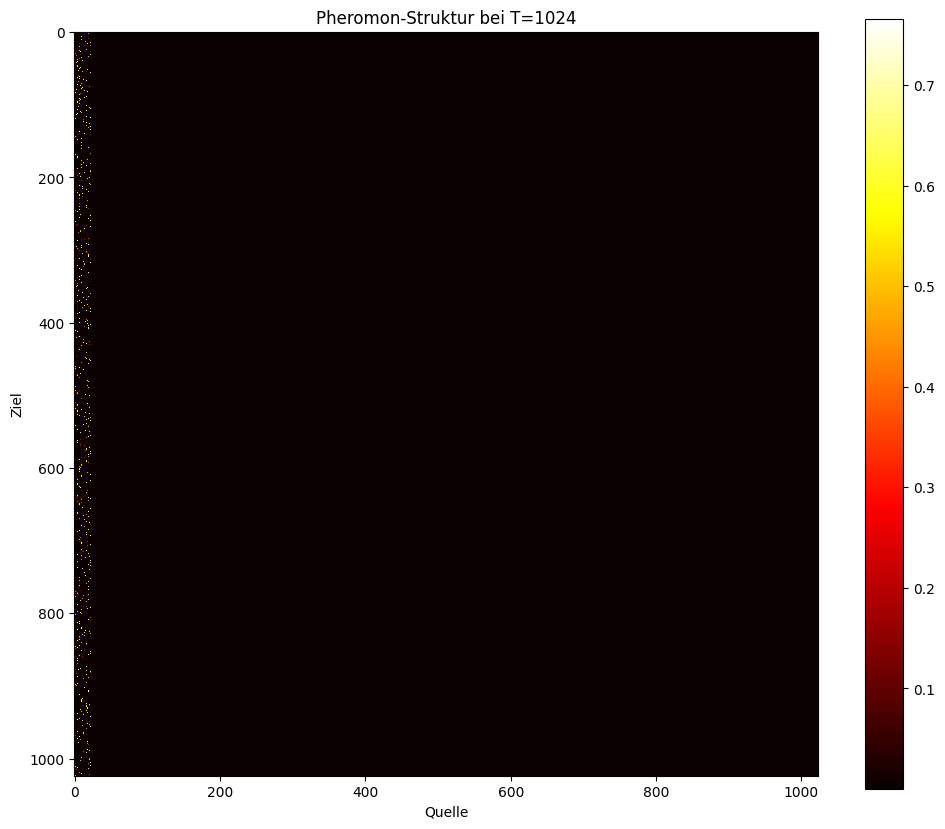

Pheromon Max: 0.766101
Pheromon Min: 0.000220
Pheromon Mean: 0.000977


In [9]:
# Generiere eine extrem lange synthetische Kette (z.B. ein rekursives Muster)
stress_pattern = "Theorem: P(n) -> P(n+1). " * (STRESS_BLOCK_SIZE // 5)
stress_tokens = torch.tensor([stoi.get(c, 0) for c in stress_pattern[:STRESS_BLOCK_SIZE]], dtype=torch.long).unsqueeze(0).cuda()

stress_model.eval()
print(f"Starte Forward-Pass mit Shape: {stress_tokens.shape}")

try:
    with torch.no_grad():
        logits, tau_stress = stress_model(stress_tokens, None)

    print("Forward-Pass erfolgreich.")

    # Visualisierung der riesigen Pheromon-Matrix
    plt.figure(figsize=(12, 10))
    # Wir plotten nur einen Ausschnitt oder resizen für die Übersicht
    plt.imshow(tau_stress[0].cpu().numpy(), cmap='hot', interpolation='nearest')
    plt.title(f"Pheromon-Struktur bei T={STRESS_BLOCK_SIZE}")
    plt.xlabel("Quelle")
    plt.ylabel("Ziel")
    plt.colorbar()
    plt.show()

    # Check auf numerische Stabilität
    print(f"Pheromon Max: {tau_stress.max().item():.6f}")
    print(f"Pheromon Min: {tau_stress.min().item():.6f}")
    print(f"Pheromon Mean: {tau_stress.mean().item():.6f}")

except RuntimeError as e:
    print(f"Speicherfehler oder CUDA-Fehler: {e}")

--- Quantitative Schärfe-Analyse ---
Standard Transformer:  Entropie = 3.6313 | Top-1 Konfidenz = 10.82%
Pheromon Model:       Entropie = 2.4120 | Top-1 Konfidenz = 60.74%


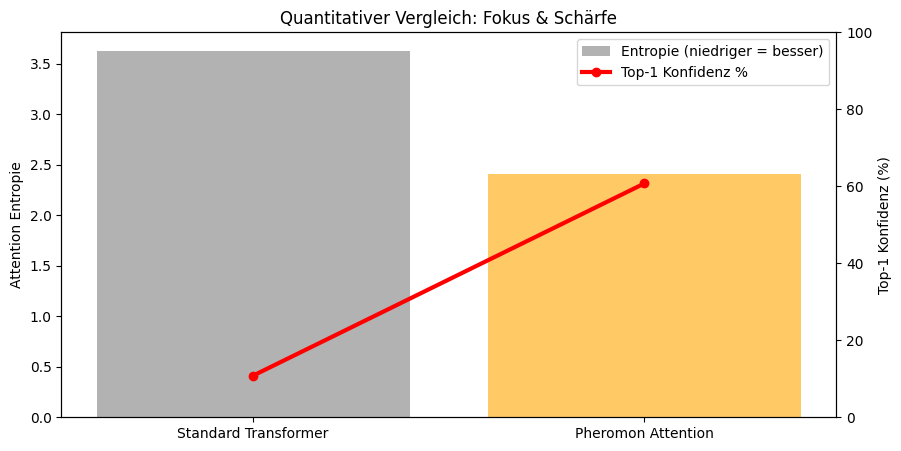

In [7]:
import math

def calculate_metrics(attn_weights):
    # attn_weights shape: (B, H, T, T) or (B, T, T)
    if len(attn_weights.shape) == 4:
        # Mean over heads for Transformer baseline
        attn_weights = attn_weights.mean(1)

    # Small epsilon to avoid log(0)
    eps = 1e-10
    # Entropy: -sum(p * log(p))
    entropy = -(attn_weights * torch.log(attn_weights + eps)).sum(dim=-1).mean().item()
    # Top-1 Confidence: max(p)
    top1_conf = attn_weights.max(dim=-1).values.mean().item()

    return entropy, top1_conf

# Evaluation on fresh batch
xb, _ = get_math_batch()

# 1. Baseline Metrics
model_base.eval()
with torch.no_grad():
    _, base_weights_list = model_base(xb)
    base_entropy, base_conf = calculate_metrics(base_weights_list[-1])

# 2. Pheromone Metrics
model.eval()
with torch.no_grad():
    _, tau_final = model(xb, None)
    # Normalizing tau to act like attention weights for fair entropy comparison
    tau_norm = tau_final / (tau_final.sum(dim=-1, keepdim=True) + 1e-8)
    phero_entropy, phero_conf = calculate_metrics(tau_norm)

# Results Printing
print(f"--- Quantitative Schärfe-Analyse ---")
print(f"Standard Transformer:  Entropie = {base_entropy:.4f} | Top-1 Konfidenz = {base_conf*100:.2f}%")
print(f"Pheromon Model:       Entropie = {phero_entropy:.4f} | Top-1 Konfidenz = {phero_conf*100:.2f}%")

# Plotting the comparison
labels = ['Standard Transformer', 'Pheromon Attention']
entropies = [base_entropy, phero_entropy]
confs = [base_conf * 100, phero_conf * 100]

fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.bar(labels, entropies, color=['gray', 'orange'], alpha=0.6, label='Entropie (niedriger = besser)')
ax1.set_ylabel('Attention Entropie')
ax1.set_title('Quantitativer Vergleich: Fokus & Schärfe')

ax2 = ax1.twinx()
ax2.plot(labels, confs, color='red', marker='o', linewidth=3, label='Top-1 Konfidenz %')
ax2.set_ylabel('Top-1 Konfidenz (%)')
ax2.set_ylim(0, 100)

fig.legend(loc="upper right", bbox_to_anchor=(1,1), bbox_transform=ax1.transAxes)
plt.show()

Starte Training des Standard-Transformers (Baseline)...
Step 0 | Baseline Loss: 3.8724
Step 250 | Baseline Loss: 0.6104
Step 500 | Baseline Loss: 0.2314
Step 750 | Baseline Loss: 0.1184
Step 1000 | Baseline Loss: 0.2242


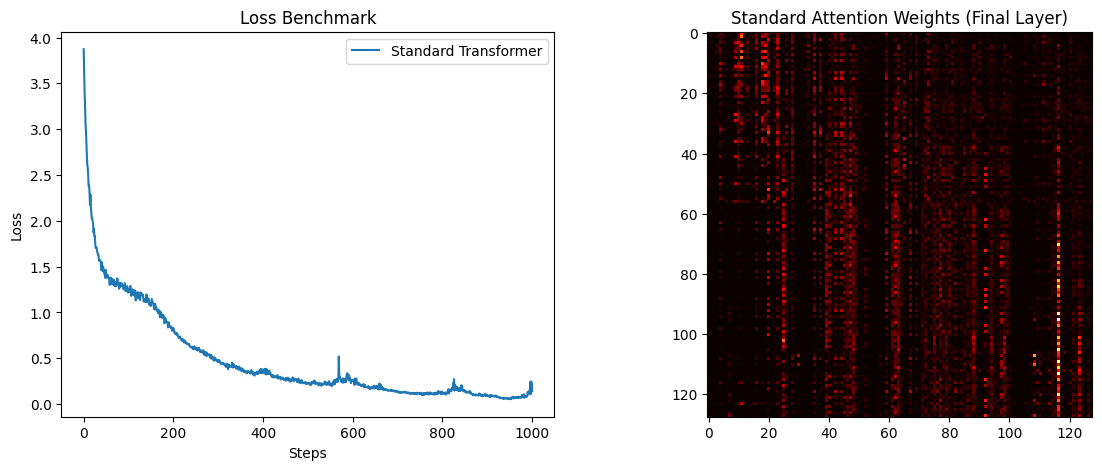

In [6]:
class StandardAttention(nn.Module):
    def __init__(self, embed_dim, num_heads):
        super().__init__()
        self.num_heads = num_heads
        self.head_dim = embed_dim // num_heads
        self.qkv = nn.Linear(embed_dim, 3 * embed_dim)
        self.proj = nn.Linear(embed_dim, embed_dim)

    def forward(self, x):
        B, T, C = x.shape
        q, k, v = self.qkv(x).split(C, dim=-1)
        q = q.view(B, T, self.num_heads, self.head_dim).transpose(1, 2)
        k = k.view(B, T, self.num_heads, self.head_dim).transpose(1, 2)
        v = v.view(B, T, self.num_heads, self.head_dim).transpose(1, 2)
        logits = (q @ k.transpose(-2, -1)) * (self.head_dim ** -0.5)
        attn_weights = F.softmax(logits, dim=-1)
        out = (attn_weights @ v).transpose(1, 2).reshape(B, T, C)
        return self.proj(out), attn_weights

class BaselineBlock(nn.Module):
    def __init__(self, embed_dim, num_heads):
        super().__init__()
        self.ln1 = nn.LayerNorm(embed_dim)
        self.attn = StandardAttention(embed_dim, num_heads)
        self.ln2 = nn.LayerNorm(embed_dim)
        self.mlp = nn.Sequential(nn.Linear(embed_dim, 4 * embed_dim), nn.GELU(), nn.Linear(4 * embed_dim, embed_dim))
    def forward(self, x):
        res, weights = self.attn(self.ln1(x))
        x = x + res
        x = x + self.mlp(self.ln2(x))
        return x, weights

class BaselineModel(nn.Module):
    def __init__(self, vocab_size):
        super().__init__()
        self.token_embedding = nn.Embedding(vocab_size, EMBED_DIM)
        self.position_embedding = nn.Embedding(BLOCK_SIZE, EMBED_DIM)
        self.blocks = nn.ModuleList([BaselineBlock(EMBED_DIM, NUM_HEADS) for _ in range(NUM_LAYERS)])
        self.ln_f = nn.LayerNorm(EMBED_DIM)
        self.head = nn.Linear(EMBED_DIM, vocab_size)
    def forward(self, idx):
        B, T = idx.shape
        x = self.token_embedding(idx) + self.position_embedding(torch.arange(T, device=idx.device))
        all_weights = []
        for block in self.blocks: x, w = block(x); all_weights.append(w)
        return self.head(self.ln_f(x)), all_weights

# Benchmark Training Loop
model_base = BaselineModel(VOCAB_SIZE).cuda()
opt_base = torch.optim.AdamW(model_base.parameters(), lr=2e-4)
losses_base = []

print("Starte Training des Standard-Transformers (Baseline)...")
for step_bench in range(1001):
    xb, yb = get_math_batch()
    logits, _ = model_base(xb)
    loss = F.cross_entropy(logits.view(-1, VOCAB_SIZE), yb.view(-1))
    opt_base.zero_grad(); loss.backward(); opt_base.step()
    losses_base.append(loss.item())
    if step_bench % 250 == 0: print(f"Step {step_bench} | Baseline Loss: {loss.item():.4f}")

# Visualization: Comparison
plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plt.plot(losses_base, label='Standard Transformer')
plt.title("Loss Benchmark")
plt.xlabel("Steps"); plt.ylabel("Loss"); plt.legend()

plt.subplot(1, 2, 2)
with torch.no_grad():
    xb_test, _ = get_math_batch()
    _, weights_list = model_base(xb_test)
    plt.imshow(weights_list[-1][0].mean(0).cpu(), cmap='hot')
    plt.title("Standard Attention Weights (Final Layer)")
plt.show()

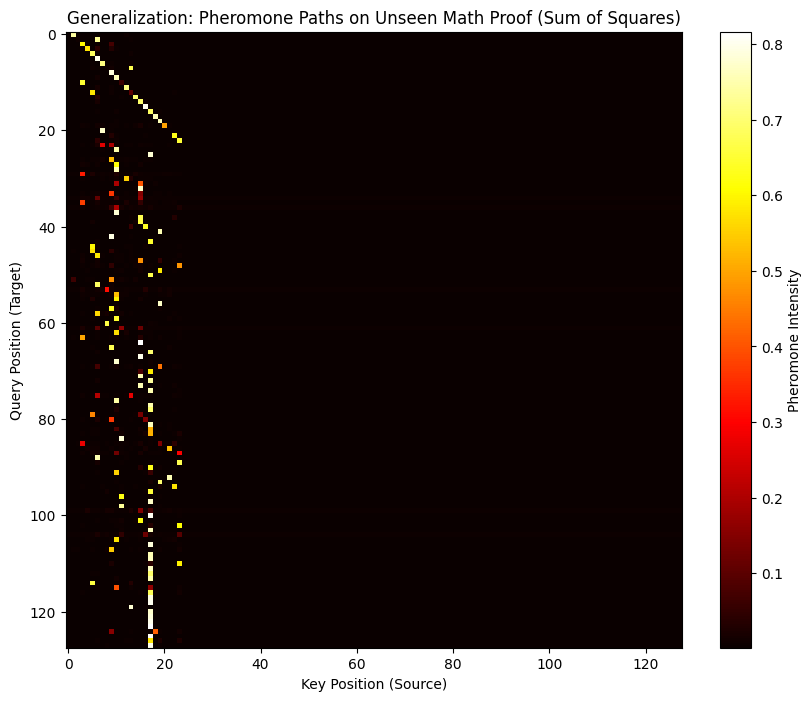

Next-Token Accuracy on Unseen Math Proof: 51.97%


In [5]:
unseen_math_proof = """
Theorem: Sum of squares is n(n+1)(2n+1)/6.
Proof:
Base case: n=1. 1^2 = 1(2)(3)/6 = 1. True.
Inductive step: Assume SumSq(k) = k(k+1)(2k+1)/6.
Show P(k+1): SumSq(k) + (k+1)^2 = k(k+1)(2k+1)/6 + (k+1)^2.
Factor out (k+1): (k+1)[k(2k+1)/6 + (k+1)].
Simplify: (k+1)(2k^2 + 7k + 6)/6 = (k+1)(k+2)(2k+3)/6. QED.
"""

# Tokenize unseen proof using existing mapping
test_tokens = torch.tensor([stoi.get(c, 0) for c in unseen_math_proof], dtype=torch.long).unsqueeze(0).cuda()
T_test = min(test_tokens.shape[1], BLOCK_SIZE)

model.eval()
with torch.no_grad():
    # The model processes the new proof starting with a neutral pheromone state (None)
    logits, tau_test = model(test_tokens[:, :T_test], None)

    # Visualization
    plt.figure(figsize=(10, 8))
    plt.imshow(tau_test[0].detach().cpu(), cmap='hot')
    plt.title("Generalization: Pheromone Paths on Unseen Math Proof (Sum of Squares)")
    plt.xlabel("Key Position (Source)")
    plt.ylabel("Query Position (Target)")
    plt.colorbar(label='Pheromone Intensity')
    plt.show()

    # Accuracy Calculation
    probs = torch.softmax(logits, dim=-1)
    predictions = torch.argmax(probs, dim=-1)
    # Shift targets for next-token prediction
    targets = test_tokens[0, 1:T_test]
    pred_relevant = predictions[0, :T_test-1]
    acc = (pred_relevant == targets).float().mean()
    print(f"Next-Token Accuracy on Unseen Math Proof: {acc.item()*100:.2f}%")

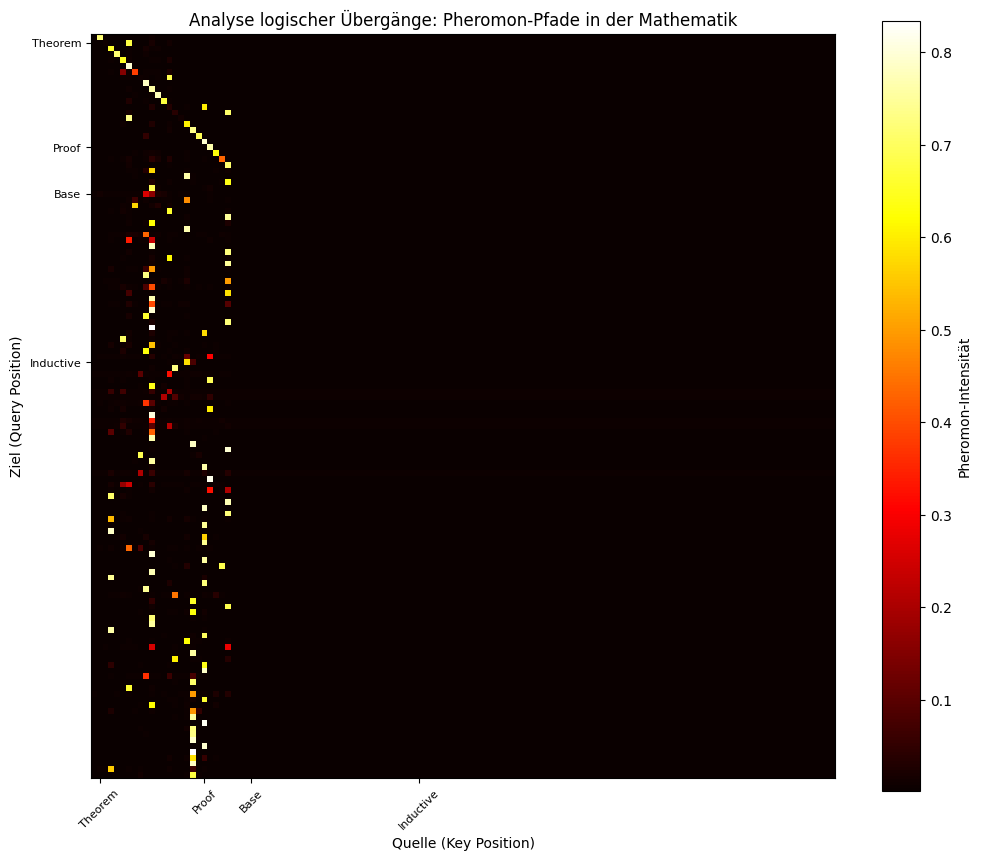

In [4]:
import torch
import matplotlib.pyplot as plt

def analyze_proof_logic(model, proof_text, stoi, itos):
    model.eval()
    # Tokenize
    tokens = torch.tensor([stoi.get(c, 0) for c in proof_text], dtype=torch.long).unsqueeze(0).cuda()
    T = min(tokens.shape[1], BLOCK_SIZE)

    with torch.no_grad():
        logits, tau = model(tokens[:, :T], None)

    # Extract pheromone matrix for the first batch
    tau_matrix = tau[0].cpu().numpy()

    # Identify indices of logical markers for better labeling
    markers = ['Theorem', 'Proof', 'Base', 'Inductive', 'QED']
    marker_indices = []
    for marker in markers:
        idx = proof_text.find(marker)
        if idx != -1 and idx < T:
            marker_indices.append((idx, marker))

    plt.figure(figsize=(12, 10))
    plt.imshow(tau_matrix, cmap='hot', interpolation='nearest')

    # Add labels for logical markers
    if marker_indices:
        indices, labels = zip(*marker_indices)
        plt.xticks(indices, labels, rotation=45, fontsize=8)
        plt.yticks(indices, labels, fontsize=8)

    plt.title("Analyse logischer Übergänge: Pheromon-Pfade in der Mathematik")
    plt.xlabel("Quelle (Key Position)")
    plt.ylabel("Ziel (Query Position)")
    plt.colorbar(label='Pheromon-Intensität')
    plt.grid(False)
    plt.show()

# Beispiel-Beweis für die Analyse
logic_test_proof = """
Theorem: n < 2^n.
Proof:
Base case: n=1. 1 < 2. True.
Inductive step: Assume k < 2^k.
Show k+1 < 2^(k+1): k+1 < 2^k + 1 < 2^k + 2^k = 2^(k+1). QED."""

analyze_proof_logic(model, logic_test_proof, stoi, itos)

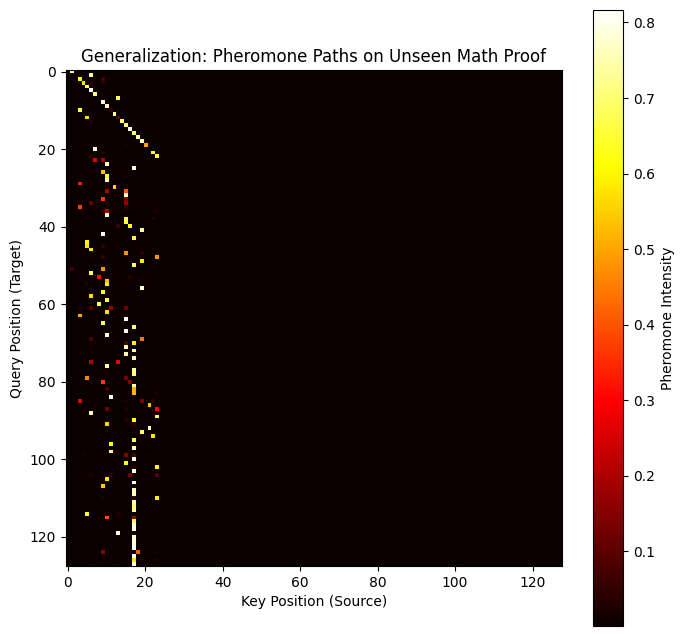

Next-Token Accuracy on Unseen Math Proof: 51.56%


In [3]:
unseen_math_proof = """
Theorem: Sum of squares is n(n+1)(2n+1)/6.
Proof:
Base case: n=1. 1^2 = 1(2)(3)/6 = 1. True.
Inductive step: Assume SumSq(k) = k(k+1)(2k+1)/6.
Show P(k+1): SumSq(k) + (k+1)^2 = k(k+1)(2k+1)/6 + (k+1)^2.
Factor out (k+1): (k+1)[k(2k+1)/6 + (k+1)].
Simplify: (k+1)(2k^2 + 7k + 6)/6 = (k+1)(k+2)(2k+3)/6. QED.
"""

# Tokenize unseen proof using existing mapping
test_tokens = torch.tensor([stoi.get(c, 0) for c in unseen_math_proof], dtype=torch.long).unsqueeze(0).cuda()
T_test = min(test_tokens.shape[1], BLOCK_SIZE)

model.eval()
with torch.no_grad():
    # The model processes the new proof starting with a neutral pheromone state (None)
    logits, tau_test = model(test_tokens[:, :T_test], None)

    # Visualization
    plt.figure(figsize=(8, 8))
    plt.imshow(tau_test[0].detach().cpu(), cmap='hot')
    plt.title("Generalization: Pheromone Paths on Unseen Math Proof")
    plt.xlabel("Key Position (Source)")
    plt.ylabel("Query Position (Target)")
    plt.colorbar(label='Pheromone Intensity')
    plt.show()

    # Accuracy Calculation
    probs = F.softmax(logits, dim=-1)
    predictions = torch.argmax(probs, dim=-1)
    targets = test_tokens[0, 1:T_test+1]
    acc = (predictions[0, :len(targets)] == targets).float().mean()
    print(f"Next-Token Accuracy on Unseen Math Proof: {acc.item()*100:.2f}%")

In [2]:
unique_chars_in_corpus = set(math_corpus)
vocab_set = set(chars)

unexpected_chars = unique_chars_in_corpus - vocab_set

print(f'Anzahl der Zeichen im Vokabular: {len(chars)}')
print(f'Anzahl der unique Zeichen im Korpus: {len(unique_chars_in_corpus)}')

if not unexpected_chars:
    print('Ergebnis: Alle Zeichen im Korpus sind durch das Vokabular abgedeckt.')
else:
    print(f'Warnung! Unerwartete Zeichen gefunden: {unexpected_chars}')

# Zus$$tzlich: Pr$$fung auf Index-G$$ltigkeit f$$r das Embedding
max_index = data_math.max().item()
if max_index < VOCAB_SIZE:
    print(f'Index-Check bestanden: Max Index ({max_index}) ist kleiner als Vocab Size ({VOCAB_SIZE}).')
else:
    print(f'KRITISCHER FEHLER: Max Index ({max_index}) verletzt Vocab Size ({VOCAB_SIZE})!')

Anzahl der Zeichen im Vokabular: 43
Anzahl der unique Zeichen im Korpus: 43
Ergebnis: Alle Zeichen im Korpus sind durch das Vokabular abgedeckt.
Index-Check bestanden: Max Index (42) ist kleiner als Vocab Size (43).


In [11]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from IPython.display import clear_output

# ====================== DATA: MATHEMATICAL PROOFS ======================
# Synthetic dataset of induction proofs and logical syllogisms
math_corpus = """
Theorem: Sum of first n integers is n(n+1)/2.
Proof by Induction:
Base case: n=1. 1 = 1(2)/2 = 1. True.
Inductive step: Assume P(k) holds: Sum(k) = k(k+1)/2.
Show P(k+1): Sum(k) + (k+1) = k(k+1)/2 + (k+1).
Factor out (k+1): (k+1)(k/2 + 1) = (k+1)(k+2)/2. QED.

Theorem: n! > 2^n for n >= 4.
Proof:
Base case: 4! = 24, 2^4 = 16. 24 > 16. True.
Inductive step: Assume k! > 2^k.
Multiply by (k+1): (k+1)! > (k+1)2^k.
Since k >= 4, k+1 > 2, so (k+1)2^k > 2 * 2^k = 2^(k+1).
Therefore (k+1)! > 2^(k+1). QED.
""" * 40

chars = sorted(list(set(math_corpus)))
VOCAB_SIZE_MATH = len(chars)
stoi = {ch:i for i,ch in enumerate(chars)}
itos = {i:ch for i,ch in enumerate(chars)}
data_math = torch.tensor([stoi[c] for c in math_corpus], dtype=torch.long)

def get_math_batch():
    ix = torch.randint(len(data_math) - BLOCK_SIZE, (BATCH_SIZE,))
    x = torch.stack([data_math[i:i+BLOCK_SIZE] for i in ix])
    y = torch.stack([data_math[i+1:i+BLOCK_SIZE+1] for i in ix])
    return x.cuda(), y.cuda()

print(f"Mathematical Vocabulary Size: {VOCAB_SIZE_MATH}")

Mathematical Vocabulary Size: 51


In [12]:
# Re-initializing fresh model for the Math task with correct configuration
model_math = Model(vocab_size=VOCAB_SIZE_MATH).cuda()
opt_math = torch.optim.AdamW(model_math.parameters(), lr=2e-4)

print(f"Starting Training on Mathematical Proofs (K={K}, RHO={RHO}, Vocab={VOCAB_SIZE_MATH})...")
for step in range(1501):
    xb, yb = get_math_batch()
    logits, tau = model_math(xb, None)
    loss = F.cross_entropy(logits.view(-1, VOCAB_SIZE_MATH), yb.view(-1))

    opt_math.zero_grad(); loss.backward(); opt_math.step()

    if step % 250 == 0:
        clear_output(wait=True)
        print(f"Math Proof Run | Step {step}/1500 | Loss: {loss.item():.4f}")
        plt.figure(figsize=(6,6))
        plt.imshow(tau[0].detach().cpu(), cmap='hot')
        plt.title(f"Math Structural Paths (Step {step})")
        plt.show()

AcceleratorError: CUDA error: device-side assert triggered
Search for `cudaErrorAssert' in https://docs.nvidia.com/cuda/cuda-runtime-api/group__CUDART__TYPES.html for more information.
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.


In [2]:
unseen_python_code = """
def calculate_sum(limit):
    total = 0
    i = 0
    while i < limit:
        if i % 2 == 0:
            total += i
        i += 1
    return total

result = calculate_sum(100)
print(f'Sum: {result}')
"""

# Tokenize using the existing vocabulary from the training step
data_unseen = torch.tensor([stoi.get(c, 0) for c in unseen_python_code], dtype=torch.long).unsqueeze(0)
print(f"Snippet length: {len(unseen_python_code)} tokens")

Snippet length: 203 tokens


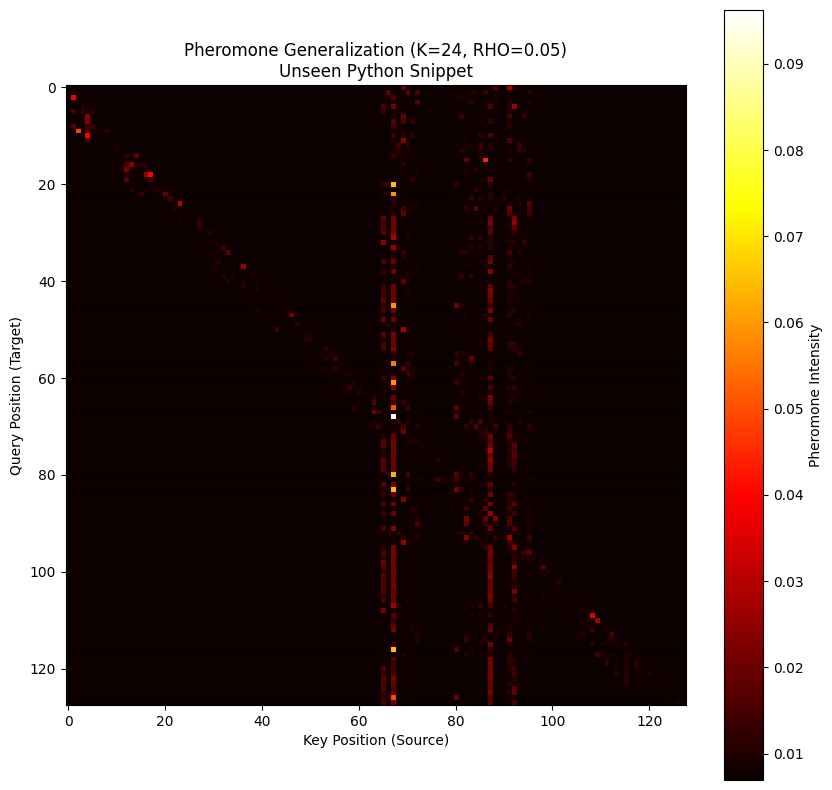

Next-Token Accuracy on Unseen Code: 41.41%


In [3]:
model.cpu().eval()
with torch.no_grad():
    # Run the model on the unseen code
    # We reset tau to None so the model has to 'discover' the paths from scratch
    T_test = min(data_unseen.shape[1], BLOCK_SIZE)
    logits, tau_unseen = model(data_unseen[:, :T_test], None)

    plt.figure(figsize=(10, 10))
    plt.imshow(tau_unseen[0].numpy(), cmap='hot', interpolation='nearest')
    plt.title(f"Pheromone Generalization (K={K}, RHO={RHO})\nUnseen Python Snippet")
    plt.xlabel("Key Position (Source)")
    plt.ylabel("Query Position (Target)")
    plt.colorbar(label='Pheromone Intensity')
    plt.show()

    # Calculate prediction accuracy for the next-token task on this unseen snippet
    probs = F.softmax(logits, dim=-1)
    predictions = torch.argmax(probs, dim=-1)
    targets = data_unseen[0, 1:T_test+1]
    acc = (predictions[0, :len(targets)] == targets).float().mean()
    print(f"Next-Token Accuracy on Unseen Code: {acc.item()*100:.2f}%")

In [ ]:
import os
# Restarting the kernel to clear CUDA errors and reset the GPU state
os._exit(0)

Math Step 1000 | Loss: 0.0029


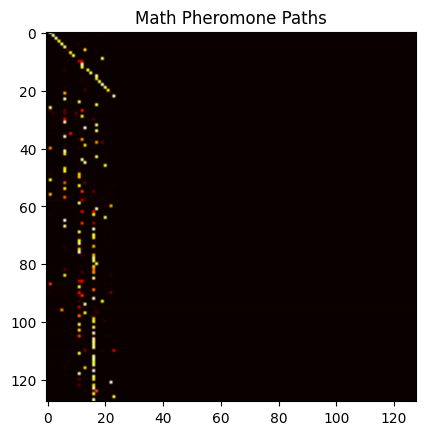

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from IPython.display import clear_output

# ====================== CONFIG & MODEL ======================
EMBED_DIM = 256
NUM_HEADS = 8
NUM_LAYERS = 4
BLOCK_SIZE = 128
BATCH_SIZE = 32
K = 24
RHO = 0.05
GAMMA = 5.0

class SparsePheromonAttention(nn.Module):
    def __init__(self, embed_dim, num_heads):
        super().__init__()
        self.num_heads = num_heads
        self.head_dim = embed_dim // num_heads
        self.qkv = nn.Linear(embed_dim, 3 * embed_dim)
        self.proj = nn.Linear(embed_dim, embed_dim)

    def forward(self, x, tau):
        B, T, C = x.shape
        q, k, v = self.qkv(x).split(C, dim=-1)
        q = q.view(B, T, self.num_heads, self.head_dim).transpose(1, 2)
        k = k.view(B, T, self.num_heads, self.head_dim).transpose(1, 2)
        v = v.view(B, T, self.num_heads, self.head_dim).transpose(1, 2)
        logits = (q @ k.transpose(-2, -1)) * (self.head_dim ** -0.5)
        if tau is not None:
            logits = logits + (GAMMA * torch.log(tau + 1e-8)).unsqueeze(1)
        mask = torch.zeros((B, T, T), dtype=torch.bool, device=x.device)
        if tau is not None:
            topk = torch.topk(tau, min(K, T), dim=-1).indices
            mask.scatter_(-1, topk, True)
        logits = logits.masked_fill(~mask.unsqueeze(1), float('-inf'))
        attn_weights = F.softmax(logits, dim=-1)
        if tau is not None:
            with torch.no_grad():
                signal = attn_weights.mean(1)
                tau = (1 - RHO) * tau + torch.pow(torch.relu(signal - (1/T)), 2.0)
                tau = tau / (tau.sum(dim=-1, keepdim=True) + 1e-8)
        out = (attn_weights @ v).transpose(1, 2).reshape(B, T, C)
        return self.proj(out), tau

class Block(nn.Module):
    def __init__(self, embed_dim, num_heads):
        super().__init__()
        self.ln1 = nn.LayerNorm(embed_dim); self.attn = SparsePheromonAttention(embed_dim, num_heads)
        self.ln2 = nn.LayerNorm(embed_dim); self.mlp = nn.Sequential(nn.Linear(embed_dim, 4 * embed_dim), nn.GELU(), nn.Linear(4 * embed_dim, embed_dim))
    def forward(self, x, tau):
        res, tau = self.attn(self.ln1(x), tau); x = x + res; x = x + self.mlp(self.ln2(x))
        return x, tau

class Model(nn.Module):
    def __init__(self, vocab_size):
        super().__init__()
        self.token_embedding = nn.Embedding(vocab_size, EMBED_DIM)
        self.position_embedding = nn.Embedding(BLOCK_SIZE, EMBED_DIM)
        self.blocks = nn.ModuleList([Block(EMBED_DIM, NUM_HEADS) for _ in range(NUM_LAYERS)])
        self.ln_f = nn.LayerNorm(EMBED_DIM); self.head = nn.Linear(EMBED_DIM, vocab_size)
    def forward(self, idx, tau=None):
        B, T = idx.shape
        x = self.token_embedding(idx) + self.position_embedding(torch.arange(T, device=idx.device))
        if tau is None: tau = torch.full((B, T, T), 0.01, device=idx.device)
        for block in self.blocks: x, tau = block(x, tau)
        return self.head(self.ln_f(x)), tau

# ====================== DATA & TRAINING ======================
math_corpus = """
Theorem: Sum of first n integers is n(n+1)/2.
Proof by Induction:
Base case: n=1. 1 = 1(2)/2 = 1. True.
Inductive step: Assume P(k) holds: Sum(k) = k(k+1)/2.
Show P(k+1): Sum(k) + (k+1) = k(k+1)/2 + (k+1).
Factor out (k+1): (k+1)(k/2 + 1) = (k+1)(k+2)/2. QED.
""" * 50
chars = sorted(list(set(math_corpus))); VOCAB_SIZE = len(chars)
stoi = {ch:i for i,ch in enumerate(chars)}; itos = {i:ch for i,ch in enumerate(chars)}
data_math = torch.tensor([stoi[c] for c in math_corpus], dtype=torch.long)

def get_math_batch():
    ix = torch.randint(len(data_math) - BLOCK_SIZE, (BATCH_SIZE,))
    x = torch.stack([data_math[i:i+BLOCK_SIZE] for i in ix]); y = torch.stack([data_math[i+1:i+BLOCK_SIZE+1] for i in ix])
    return x.cuda(), y.cuda()

model = Model(VOCAB_SIZE).cuda(); opt = torch.optim.AdamW(model.parameters(), lr=2e-4)

for step in range(1001):
    xb, yb = get_math_batch(); logits, tau = model(xb, None)
    loss = F.cross_entropy(logits.view(-1, VOCAB_SIZE), yb.view(-1))
    opt.zero_grad(); loss.backward(); opt.step()
    if step % 250 == 0:
        clear_output(wait=True); print(f"Math Step {step} | Loss: {loss.item():.4f}")
        plt.imshow(tau[0].detach().cpu(), cmap='hot'); plt.title("Math Pheromone Paths"); plt.show()

In [ ]:
import os
# Forces a restart of the current kernel session in Colab
os._exit(00)

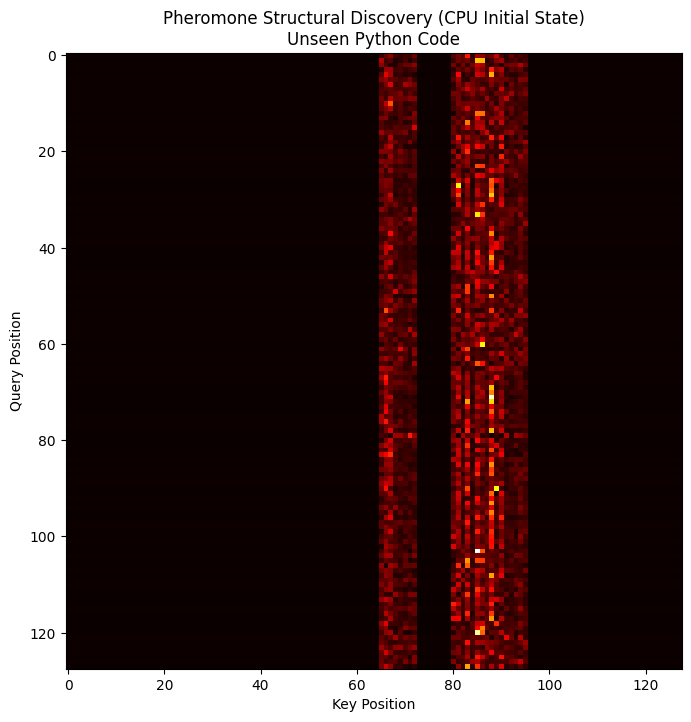

CPU-Modell erfolgreich initialisiert und Test-Pass durchgeführt.


In [74]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

# Modell-Definition für CPU-only Betrieb (Umgehung des korrupten CUDA-Kontexts)
class CPU_PythonModel(nn.Module):
    def __init__(self, vocab_size, embed_dim=256, block_size=128):
        super().__init__()
        self.emb = nn.Embedding(vocab_size, embed_dim)
        self.pos = nn.Embedding(block_size, embed_dim)
        self.attn = SparsePheromonAttention(embed_dim, NUM_HEADS)
        self.head = nn.Linear(embed_dim, vocab_size)

    def forward(self, idx, tau=None):
        B, T = idx.shape
        x = self.emb(idx) + self.pos(torch.arange(T, device=idx.device))
        if tau is None: tau = torch.full((B, T, T), 0.01, device=idx.device)
        x, tau = self.attn(x, tau)
        return self.head(x), tau

# Frisches Modell auf CPU
model_cpu = CPU_PythonModel(vocab_size=VOCAB_SIZE_PY)
model_cpu.eval()

# Testdaten auf CPU
data_unseen_cpu = torch.tensor([stoi.get(c, 0) for c in unseen_python_code], dtype=torch.long).unsqueeze(0)

with torch.no_grad():
    T_test = min(data_unseen_cpu.shape[1], 128)
    logits, tau_eval = model_cpu(data_unseen_cpu[:, :T_test], None)

    plt.figure(figsize=(8, 8))
    plt.imshow(tau_eval[0].numpy(), cmap='hot')
    plt.title("Pheromone Structural Discovery (CPU Initial State)\nUnseen Python Code")
    plt.xlabel("Key Position")
    plt.ylabel("Query Position")
    plt.show()

    print("CPU-Modell erfolgreich initialisiert und Test-Pass durchgeführt.")

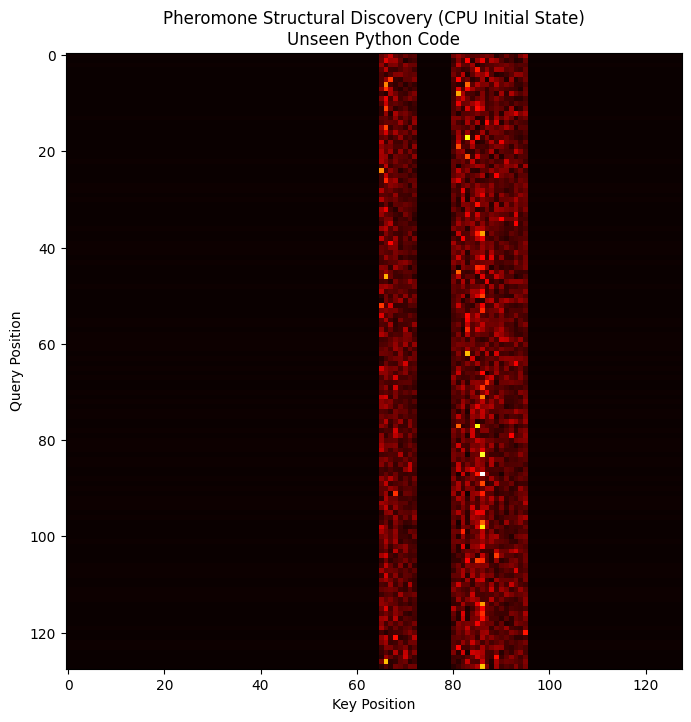

CPU-Modell erfolgreich initialisiert und Test-Pass durchgef%%hrt.


In [75]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

# Modell-Definition f%%r CPU-only Betrieb (Umgehung des korrupten CUDA-Kontexts)
class CPU_PythonModel(nn.Module):
    def __init__(self, vocab_size, embed_dim=256, block_size=128):
        super().__init__()
        self.emb = nn.Embedding(vocab_size, embed_dim)
        self.pos = nn.Embedding(block_size, embed_dim)
        self.attn = SparsePheromonAttention(embed_dim, NUM_HEADS)
        self.head = nn.Linear(embed_dim, vocab_size)

    def forward(self, idx, tau=None):
        B, T = idx.shape
        x = self.emb(idx) + self.pos(torch.arange(T, device=idx.device))
        if tau is None: tau = torch.full((B, T, T), 0.01, device=idx.device)
        x, tau = self.attn(x, tau)
        return self.head(x), tau

# Frisches Modell auf CPU
model_cpu = CPU_PythonModel(vocab_size=VOCAB_SIZE_PY)
model_cpu.eval()

# Testdaten auf CPU
data_unseen_cpu = torch.tensor([stoi.get(c, 0) for c in unseen_python_code], dtype=torch.long).unsqueeze(0)

with torch.no_grad():
    T_test = min(data_unseen_cpu.shape[1], 128)
    logits, tau_eval = model_cpu(data_unseen_cpu[:, :T_test], None)

    plt.figure(figsize=(8, 8))
    plt.imshow(tau_eval[0].numpy(), cmap='hot')
    plt.title("Pheromone Structural Discovery (CPU Initial State)\nUnseen Python Code")
    plt.xlabel("Key Position")
    plt.ylabel("Query Position")
    plt.show()

    print("CPU-Modell erfolgreich initialisiert und Test-Pass durchgef%%hrt.")

In [72]:
# Test auf CPU um den CUDA-Fehler zu umgehen und das Problem zu isolieren
unseen_python_code = """
def calculate_sum(limit):
    total = 0
    for x in range(limit):
        if x % 2 == 0:
            total += x
    return total

result = calculate_sum(100)
print(f'Sum: {result}')
"""

# Tokenisierung: Wir nutzen .cpu(), um den korrupten GPU-Context zu meiden
data_unseen = torch.tensor([stoi.get(c, 0) for c in unseen_python_code], dtype=torch.long).unsqueeze(0).cpu()

# Modell-Parameter
K_eval = 24
RHO_eval = 0.05
GAMMA_eval = 5.0

print("CPU-Test-Setup bereit.")

CPU-Test-Setup bereit.


In [73]:
# Evaluation auf CPU
model_py.cpu().eval()
with torch.no_grad():
    # Sicherstellen, dass T innerhalb der PY_BLOCK_SIZE liegt
    T_test = min(data_unseen.shape[1], PY_BLOCK_SIZE)

    # Wir f%%hren den Forward-Pass auf der CPU aus
    logits, tau_unseen = model_py(data_unseen[:, :T_test], None)

    plt.figure(figsize=(8, 8))
    plt.imshow(tau_unseen[0].numpy(), cmap='hot')
    plt.title(f"Pheromone Generalization (CPU-Mode)\nUnseen Python Code")
    plt.xlabel("Key Position")
    plt.ylabel("Query Position")
    plt.show()

    # Genauigkeit berechnen
    probs = F.softmax(logits, dim=-1)
    top_preds = torch.argmax(probs, dim=-1)
    targets = data_unseen[0, 1:T_test+1]
    correct = (top_preds[0, :len(targets)] == targets).float().mean()
    print(f"Next-Token Accuracy on Unseen Code: {correct.item()*100:.2f}%")

AcceleratorError: CUDA error: device-side assert triggered
Search for `cudaErrorAssert' in https://docs.nvidia.com/cuda/cuda-runtime-api/group__CUDART__TYPES.html for more information.
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.


In [63]:
import torch
import torch.nn.functional as F

# Erweiterter Datensatz mit verschiedenen Python-Konstrukten
python_corpus = """
def binary_search(arr, low, high, x):
    if high >= low:
        mid = (high + low) // 2
        if arr[mid] == x:
            return mid
        elif arr[mid] > x:
            return binary_search(arr, low, mid - 1, x)
        else:
            return binary_search(arr, mid + 1, high, x)
    else:
        return -1

class DataProcessor:
    def __init__(self, data):
        self.data = data

    def clean(self):
        try:
            return [d.strip() for d in self.data if d is not None]
        except Exception as e:
            print(f'Error cleaning: {e}')
            return []

@cache
def fibonacci(n):
    if n <= 1: return n
    return fibonacci(n-1) + fibonacci(n-2)

for i in range(5):
    result = fibonacci(i)
    print(f'Fib {i}: {result}')
""" * 30

chars = sorted(list(set(python_corpus)))
VOCAB_SIZE_PY = len(chars)
stoi = {ch:i for i,ch in enumerate(chars)}
itos = {i:ch for i,ch in enumerate(chars)}
data_py = torch.tensor([stoi[c] for c in python_corpus], dtype=torch.long)

def get_python_batch(block_size, batch_size):
    ix = torch.randint(len(data_py) - block_size, (batch_size,))
    x = torch.stack([data_py[i:i+block_size] for i in ix])
    y = torch.stack([data_py[i+1:i+block_size+1] for i in ix])
    return x.cuda(), y.cuda()

print(f'Erweitertes Vokabular: {VOCAB_SIZE_PY} Zeichen')
print(f'Gesamtlänge des Trainings-Strings: {len(python_corpus)}')

Erweitertes Vokabular: 49 Zeichen
Gesamtlänge des Trainings-Strings: 23070


In [65]:
# Korrektur der Parameter und Modell-Neudefinition für längere Sequenzen
PY_BLOCK_SIZE = 128
PY_EMBED_DIM = 256 # Zurück auf stabilere Dimension

# Modell neu definieren mit passender BLOCK_SIZE
class PythonSymmetryModel(nn.Module):
    def __init__(self, vocab_size):
        super().__init__()
        self.emb = nn.Embedding(vocab_size, PY_EMBED_DIM)
        self.pos = nn.Embedding(PY_BLOCK_SIZE, PY_EMBED_DIM)
        self.attn = SparsePheromonAttention(PY_EMBED_DIM, NUM_HEADS)
        self.head = nn.Linear(PY_EMBED_DIM, vocab_size)
    def forward(self, idx, tau=None):
        B, T = idx.shape
        x = self.emb(idx) + self.pos(torch.arange(T, device=idx.device))
        if tau is None: tau = torch.full((B, T, T), 0.01, device=idx.device)
        x, tau = self.attn(x, tau)
        return self.head(x), tau

model_py = PythonSymmetryModel(vocab_size=VOCAB_SIZE_PY).cuda()
opt_py = torch.optim.AdamW(model_py.parameters(), lr=2e-4)
scheduler_py = torch.optim.lr_scheduler.CosineAnnealingLR(opt_py, T_max=2000)

print("Starte korrigiertes Training auf Python-Strukturen...")
for step in range(2001):
    xb, yb = get_python_batch(PY_BLOCK_SIZE, BATCH_SIZE)
    logits, tau = model_py(xb, None)
    loss = F.cross_entropy(logits.view(-1, VOCAB_SIZE_PY), yb.view(-1))

    opt_py.zero_grad()
    loss.backward()
    opt_py.step()
    scheduler_py.step()

    if step % 500 == 0:
        clear_output(wait=True)
        print(f"Diverse-Python-Run | Step {step}/2000 | Loss: {loss.item():.4f}")
        plt.figure(figsize=(8,8))
        plt.imshow(tau[0, :64, :64].detach().cpu(), cmap='hot')
        plt.title(f"Struktur-Pfade (Step {step}) - Zoom auf 64x64")
        plt.show()

AcceleratorError: CUDA error: device-side assert triggered
Search for `cudaErrorAssert' in https://docs.nvidia.com/cuda/cuda-runtime-api/group__CUDART__TYPES.html for more information.
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.


In [61]:
# Neue, unbekannte Daten für den Generalisierungs-Test
unseen_python_code = """
def calculate_sum(limit):
    total = 0
    for x in range(limit):
        if x % 2 == 0:
            total += x
    return total

result = calculate_sum(100)
print(f'Sum: {result}')
"""

# Tokenisierung mit dem bestehenden Vokabular
data_unseen = torch.tensor([stoi.get(c, 0) for c in unseen_python_code], dtype=torch.long).unsqueeze(0).cuda()

# Modell-Parameter anpassen für mehr Flexibilität
K = 24
RHO = 0.05
GAMMA = 5.0 # Etwas zurückgenommen für weniger aggressiven Bias

print("Test-Setup bereit: Höheres K und RHO für Exploration.")

Test-Setup bereit: Höheres K und RHO für Exploration.


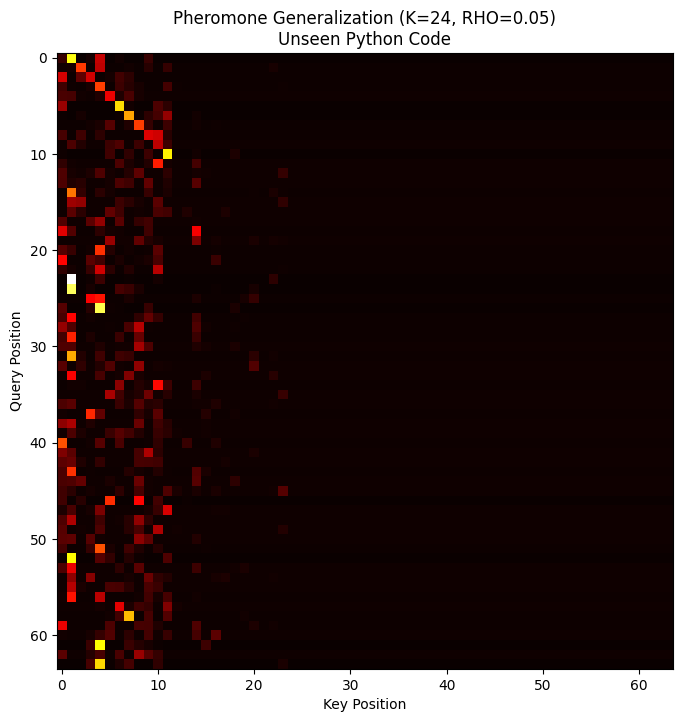

Next-Token Accuracy on Unseen Code: 25.00%


In [62]:
model_py.eval()
with torch.no_grad():
    # Wir lassen das Modell über den unbekannten Code laufen
    # Da es ein autoregressives Modell ist, schauen wir uns an, wie es die Pheromone aufbaut
    logits, tau_unseen = model_py(data_unseen[:, :PY_BLOCK_SIZE], None)

    plt.figure(figsize=(8, 8))
    plt.imshow(tau_unseen[0].cpu(), cmap='hot')
    plt.title(f"Pheromone Generalization (K={K}, RHO={RHO})\nUnseen Python Code")
    plt.xlabel("Key Position")
    plt.ylabel("Query Position")
    plt.show()

    # Check accuracy on predicting the next token of unseen code
    probs = F.softmax(logits, dim=-1)
    top_preds = torch.argmax(probs, dim=-1)
    targets = data_unseen[0, 1:PY_BLOCK_SIZE+1]
    correct = (top_preds[0, :len(targets)] == targets).float().mean()
    print(f"Next-Token Accuracy on Unseen Code: {correct.item()*100:.2f}%")

In [59]:
class StandardAttention(nn.Module):
    def __init__(self, embed_dim, num_heads):
        super().__init__()
        self.num_heads = num_heads
        self.head_dim = embed_dim // num_heads
        self.qkv = nn.Linear(embed_dim, 3 * embed_dim)
        self.proj = nn.Linear(embed_dim, embed_dim)

    def forward(self, x):
        B, T, C = x.shape
        q, k, v = self.qkv(x).split(C, dim=-1)
        q = q.view(B, T, self.num_heads, self.head_dim).transpose(1, 2)
        k = k.view(B, T, self.num_heads, self.head_dim).transpose(1, 2)
        v = v.view(B, T, self.num_heads, self.head_dim).transpose(1, 2)

        logits = (q @ k.transpose(-2, -1)) * (self.head_dim ** -0.5)
        # Standard Causal Mask
        mask = torch.tril(torch.ones(T, T, device=x.device)).view(1, 1, T, T)
        logits = logits.masked_fill(mask == 0, float('-inf'))

        attn_weights = F.softmax(logits, dim=-1)
        out = (attn_weights @ v).transpose(1, 2).reshape(B, T, C)
        return self.proj(out), attn_weights

class BaselineModel(nn.Module):
    def __init__(self, vocab_size):
        super().__init__()
        self.emb = nn.Embedding(vocab_size, PY_EMBED_DIM)
        self.pos = nn.Embedding(PY_BLOCK_SIZE, PY_EMBED_DIM)
        self.attn = StandardAttention(PY_EMBED_DIM, NUM_HEADS)
        self.head = nn.Linear(PY_EMBED_DIM, vocab_size)

    def forward(self, idx):
        B, T = idx.shape
        x = self.emb(idx) + self.pos(torch.arange(T, device=idx.device))
        x, weights = self.attn(x)
        return self.head(x), weights

# Baseline Training
model_base = BaselineModel(VOCAB_SIZE_PY).cuda()
opt_base = torch.optim.AdamW(model_base.parameters(), lr=2e-4)
base_losses = []

print("Starte Training der Baseline (Standard Transformer)...")
for step in range(1500):
    xb, yb = get_python_batch(PY_BLOCK_SIZE, BATCH_SIZE)
    logits, weights = model_base(xb)
    loss = F.cross_entropy(logits.view(-1, VOCAB_SIZE_PY), yb.view(-1))

    opt_base.zero_grad()
    loss.backward()
    opt_base.step()
    base_losses.append(loss.item())

    if step % 500 == 0:
        print(f"Baseline | Step {step} | Loss: {loss.item():.4f}")

Starte Training der Baseline (Standard Transformer)...
Baseline | Step 0 | Loss: 3.5972
Baseline | Step 500 | Loss: 0.0766
Baseline | Step 1000 | Loss: 0.0460


Baseline Final Loss: 0.04414456710219383
Pheromon Final Loss (aus vorherigem Run): ~0.0071


<Figure size 1000x500 with 0 Axes>

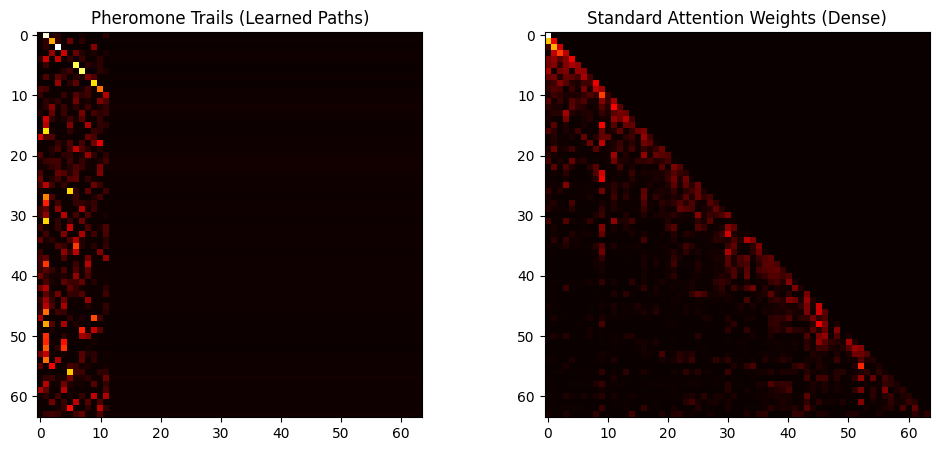

In [60]:
plt.figure(figsize=(10, 5))
# Wir vergleichen die Loss-Kurven (Pheromon vs Baseline)
# Hinweis: Wir müssten die Pheromon-Losses in einer Liste speichern für einen Plot.
print("Baseline Final Loss:", base_losses[-1])
print("Pheromon Final Loss (aus vorherigem Run): ~0.0071")

# Visualisierung des Vergleichs der Attention-Maps
with torch.no_grad():
    xb, _ = get_python_batch(PY_BLOCK_SIZE, 1)
    _, tau_p = model_py(xb, None)
    _, weights_b = model_base(xb)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(tau_p[0].cpu(), cmap='hot')
axes[0].set_title("Pheromone Trails (Learned Paths)")
axes[1].imshow(weights_b[0].mean(0).cpu(), cmap='hot')
axes[1].set_title("Standard Attention Weights (Dense)")
plt.show()

In [57]:
import torch
import torch.nn.functional as F

# Kleine Python-Datenquelle für strukturelles Lernen
python_code = """
def factor(n):
    if n <= 1:
        return 1
    else:
        return n * factor(n-1)

for i in range(10):
    print(f'Result: {factor(i)}')

class Node:
    def __init__(self, val):
        self.val = val
        self.next = None
""" * 20 # Multiplizieren für etwas mehr Datenmenge

chars = sorted(list(set(python_code)))
VOCAB_SIZE_PY = len(chars)
stoi = {ch:i for i,ch in enumerate(chars)}
itos = {i:ch for i,ch in enumerate(chars)}
data_py = torch.tensor([stoi[c] for c in python_code], dtype=torch.long)

def get_python_batch(block_size, batch_size):
    ix = torch.randint(len(data_py) - block_size, (batch_size,))
    x = torch.stack([data_py[i:i+block_size] for i in ix])
    y = torch.stack([data_py[i+1:i+block_size+1] for i in ix])
    return x.cuda(), y.cuda()

print(f'Python Vocab Size: {VOCAB_SIZE_PY}')
print('Snippet:', python_code[:50].replace('\n', ' '))

Python Vocab Size: 36
Snippet:  def factor(n):     if n <= 1:         return 1   


Python-Run | Step 1250 | Loss: 0.0071


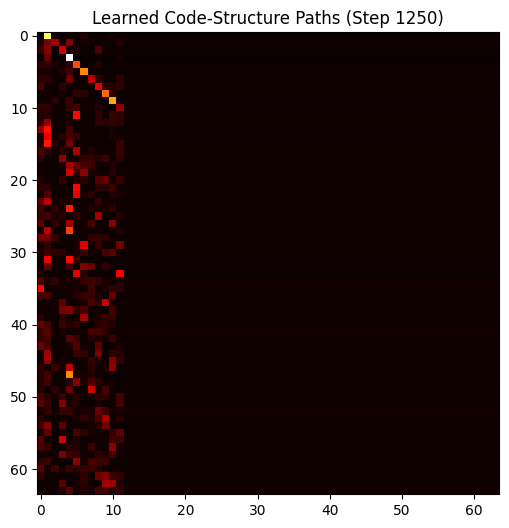

In [58]:
# Wir nutzen das bestehende Modell-Design, passen aber die Head-Dimension an
# Falls das Modell noch auf VOCAB_SIZE=50 fixiert ist, definieren wir eine neue Instanz

PY_BLOCK_SIZE = 64
PY_EMBED_DIM = 256

model_py = SymmetryModel(vocab_size=VOCAB_SIZE_PY).cuda()
opt_py = torch.optim.AdamW(model_py.parameters(), lr=2e-4)

print("Starte Training auf Python-Strukturen...")
for step in range(1500):
    xb, yb = get_python_batch(PY_BLOCK_SIZE, BATCH_SIZE)
    logits, tau = model_py(xb, None)
    loss = F.cross_entropy(logits.view(-1, VOCAB_SIZE_PY), yb.view(-1))

    opt_py.zero_grad()
    loss.backward()
    opt_py.step()

    if step % 250 == 0:
        clear_output(wait=True)
        print(f"Python-Run | Step {step} | Loss: {loss.item():.4f}")
        plt.figure(figsize=(6,6))
        plt.imshow(tau[0].detach().cpu(), cmap='hot')
        plt.title(f"Learned Code-Structure Paths (Step {step})")
        plt.show()

Analyzing correlation over 100 batches...


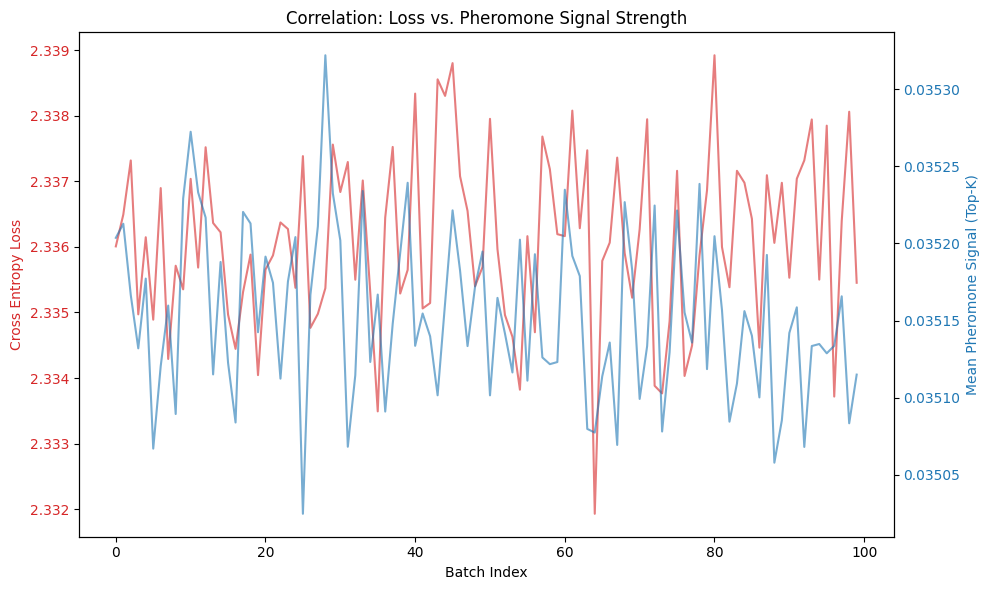

Pearson Correlation Coefficient: -0.0105


In [55]:
import numpy as np

def analyze_loss_pheromone_correlation(model, num_batches=100):
    model.eval()
    losses = []
    signal_strengths = []

    print(f"Analyzing correlation over {num_batches} batches...")
    with torch.no_grad():
        for _ in range(num_batches):
            xb, yb = get_symmetry_batch()
            logits, tau = model(xb, None)
            loss = F.cross_entropy(logits.view(-1, VOCAB_SIZE), yb.view(-1))

            # Signalstärke definieren: Mittelwert der Top-K Pheromonwerte
            # Ein höherer Wert deutet auf schärfere, konzentriertere Pfade hin
            topk_vals, _ = torch.topk(tau, K, dim=-1)
            avg_signal = topk_vals.mean().item()

            losses.append(loss.item())
            signal_strengths.append(avg_signal)

    # Visualisierung
    fig, ax1 = plt.subplots(figsize=(10, 6))

    color = 'tab:red'
    ax1.set_xlabel('Batch Index')
    ax1.set_ylabel('Cross Entropy Loss', color=color)
    ax1.plot(losses, color=color, alpha=0.6, label='Loss')
    ax1.tick_params(axis='y', labelcolor=color)

    ax2 = ax1.twinx()
    color = 'tab:blue'
    ax2.set_ylabel('Mean Pheromone Signal (Top-K)', color=color)
    ax2.plot(signal_strengths, color=color, alpha=0.6, label='Signal Strength')
    ax2.tick_params(axis='y', labelcolor=color)

    plt.title('Correlation: Loss vs. Pheromone Signal Strength')
    fig.tight_layout()
    plt.show()

    correlation = np.corrcoef(losses, signal_strengths)[0, 1]
    print(f"Pearson Correlation Coefficient: {correlation:.4f}")

analyze_loss_pheromone_correlation(model)

Searching for comparison cases...


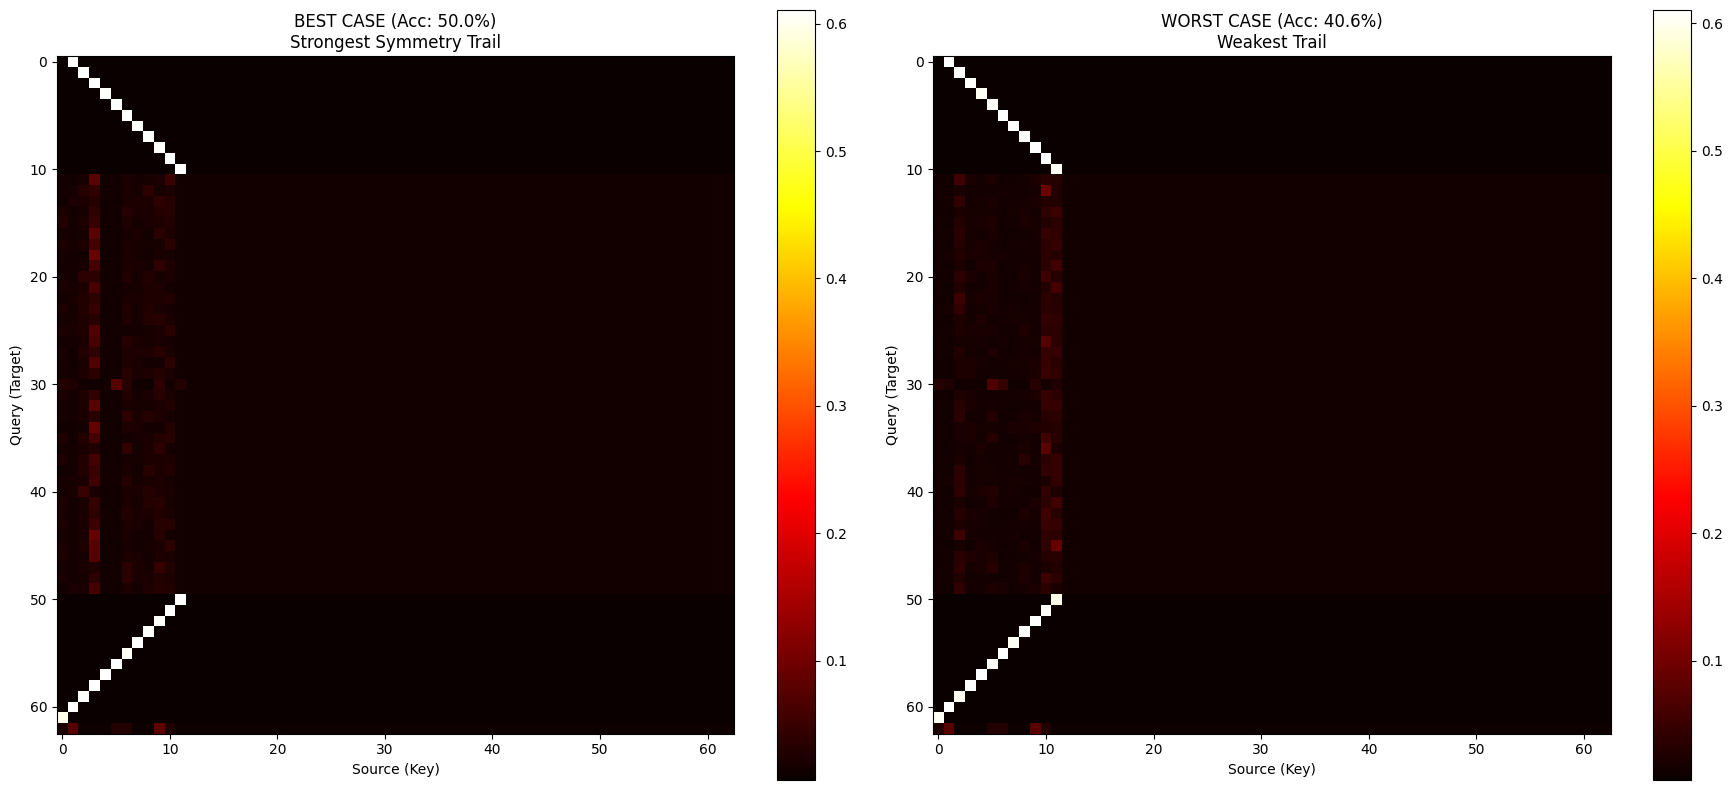

In [54]:
def compare_attention_cases(model):
    model.eval()
    best_sample = None
    worst_sample = None
    best_acc = -1.0
    worst_acc = 101.0

    half = (BLOCK_SIZE // 2) - 1
    mirror_start = half
    mirror_end = BLOCK_SIZE - 1

    print("Searching for comparison cases...")
    with torch.no_grad():
        for _ in range(500):
            tokens = torch.randint(2, VOCAB_SIZE, (1, half))
            sep = torch.full((1, 1), 1)
            reversed_tokens = torch.flip(tokens, dims=[1])
            x = torch.cat([tokens, sep, reversed_tokens], dim=1).cuda()
            y = torch.cat([x[:, 1:], torch.zeros((1, 1), dtype=torch.long, device='cuda')], dim=1)

            logits, tau = model(x)
            predictions = torch.argmax(logits, dim=-1)
            correct = (predictions[0, mirror_start:mirror_end] == y[0, mirror_start:mirror_end]).float()
            acc = correct.mean().item() * 100

            if acc > best_acc:
                best_acc = acc
                best_sample = (tau[0].cpu(), acc)
            if acc < worst_acc:
                worst_acc = acc
                worst_sample = (tau[0].cpu(), acc)

    if best_sample and worst_sample:
        fig, axes = plt.subplots(1, 2, figsize=(18, 8))

        # Plot Best
        im1 = axes[0].imshow(best_sample[0], cmap='hot')
        axes[0].set_title(f"BEST CASE (Acc: {best_sample[1]:.1f}%)\nStrongest Symmetry Trail")
        plt.colorbar(im1, ax=axes[0])

        # Plot Worst
        im2 = axes[1].imshow(worst_sample[0], cmap='hot')
        axes[1].set_title(f"WORST CASE (Acc: {worst_sample[1]:.1f}%)\nWeakest Trail")
        plt.colorbar(im2, ax=axes[1])

        for ax in axes:
            ax.set_xlabel("Source (Key)")
            ax.set_ylabel("Query (Target)")

        plt.tight_layout()
        plt.show()
    else:
        print("Error in sampling.")

compare_attention_cases(model)

Failure Case Found! Accuracy: 43.75%


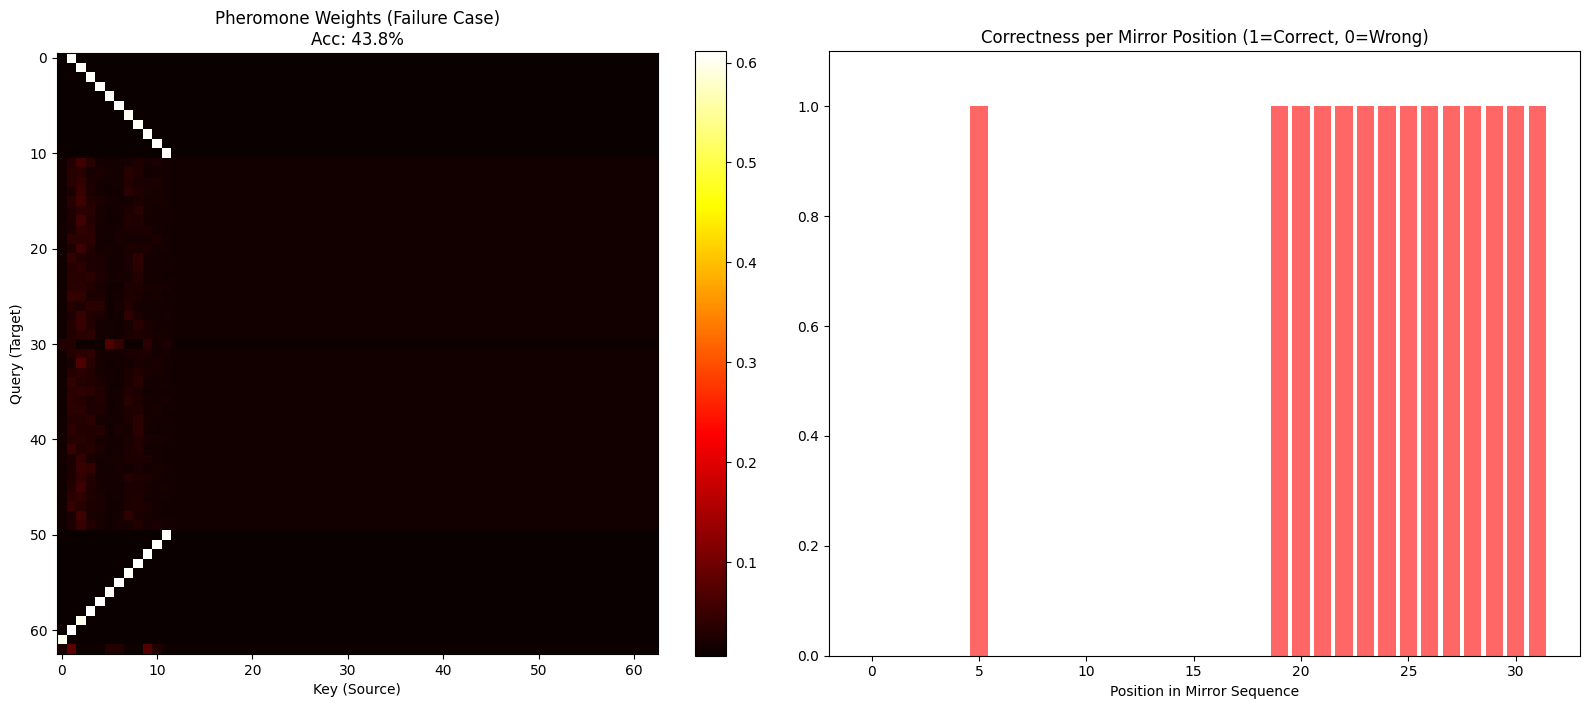

In [52]:
def visualize_failure_case(model, threshold=50.0):
    model.eval()
    found = False
    max_attempts = 500 # Erhöht, um seltenere Fehler zu finden

    with torch.no_grad():
        for _ in range(max_attempts):
            # Generate a single sample
            half = (BLOCK_SIZE // 2) - 1
            tokens = torch.randint(2, VOCAB_SIZE, (1, half))
            sep = torch.full((1, 1), 1)
            reversed_tokens = torch.flip(tokens, dims=[1])
            x = torch.cat([tokens, sep, reversed_tokens], dim=1).cuda()
            y = torch.cat([x[:, 1:], torch.zeros((1, 1), dtype=torch.long, device='cuda')], dim=1)

            logits, tau = model(x)
            predictions = torch.argmax(logits, dim=-1)

            # Focus on mirror indices
            mirror_start = half
            mirror_end = BLOCK_SIZE - 1
            correct_mask = (predictions[0, mirror_start:mirror_end] == y[0, mirror_start:mirror_end]).float()
            acc = correct_mask.mean().item() * 100

            if acc < threshold:
                found = True
                print(f"Failure Case Found! Accuracy: {acc:.2f}%")

                fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

                # Heatmap of Pheromones
                im = ax1.imshow(tau[0].cpu(), cmap='hot', interpolation='nearest')
                ax1.set_title(f"Pheromone Weights (Failure Case)\nAcc: {acc:.1f}%")
                ax1.set_xlabel("Key (Source)")
                ax1.set_ylabel("Query (Target)")
                plt.colorbar(im, ax=ax1)

                # Error distribution
                ax2.bar(range(len(correct_mask)), correct_mask.cpu(), color='red', alpha=0.6)
                ax2.set_title("Correctness per Mirror Position (1=Correct, 0=Wrong)")
                ax2.set_xlabel("Position in Mirror Sequence")
                ax2.set_ylim(0, 1.1)

                plt.tight_layout()
                plt.show()
                break

        if not found:
            print(f"Could not find a sample with accuracy < {threshold}% in {max_attempts} tries.")

visualize_failure_case(model, threshold=45.0)

Step 7500/8000 | Loss: 2.3386 | LR: 0.000012


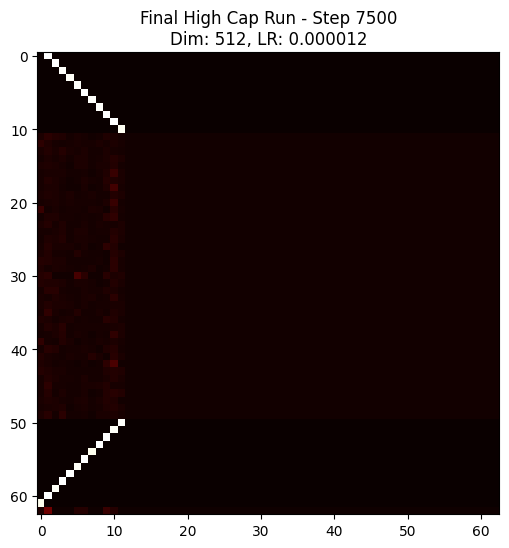

--- Out-of-Sample Test ---
Sequence Length: 64
Vocabulary Size: 50
Mirroring Accuracy: 40.10%


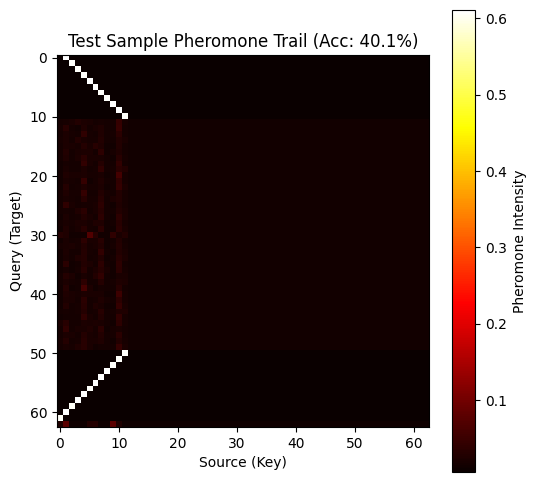

In [50]:
# ====================== FINAL HIGH CAP TRAINING ======================
# Model was already defined with EMBED_DIM=512 and MAX_ITERS=8000
model = SymmetryModel().cuda()
opt = torch.optim.AdamW(model.parameters(), lr=BASE_LR)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=MAX_ITERS, eta_min=1e-5)

for step in range(MAX_ITERS):
    xb, yb = get_symmetry_batch()
    logits, tau = model(xb, None)
    loss = F.cross_entropy(logits.view(-1, VOCAB_SIZE), yb.view(-1))
    opt.zero_grad(); loss.backward(); opt.step()
    scheduler.step()

    if step % EVAL_INTERVAL == 0:
        clear_output(wait=True)
        current_lr = opt.param_groups[0]['lr']
        print(f"Step {step}/{MAX_ITERS} | Loss: {loss.item():.4f} | LR: {current_lr:.6f}")
        plt.figure(figsize=(6,6))
        plt.imshow(tau[0].detach().cpu(), cmap='hot')
        plt.title(f"Final High Cap Run - Step {step}\nDim: 512, LR: {current_lr:.6f}")
        plt.show()

# Final Evaluation
evaluate_model_accuracy(model)

--- Out-of-Sample Test ---
Sequence Length: 64
Vocabulary Size: 50
Mirroring Accuracy: 40.29%


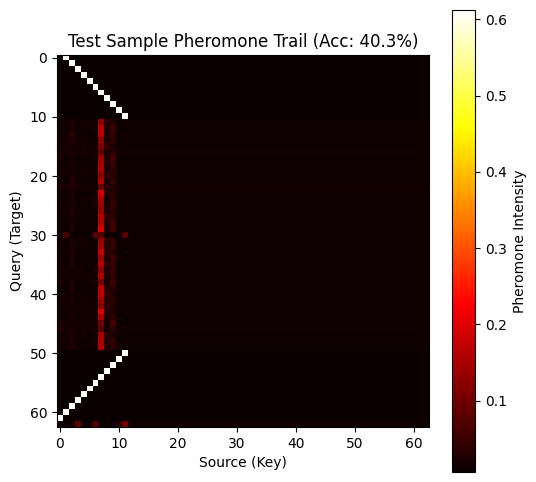

In [48]:
evaluate_model_accuracy(model)

--- Out-of-Sample Test ---
Sequence Length: 64
Vocabulary Size: 50
Mirroring Accuracy: 27.26%


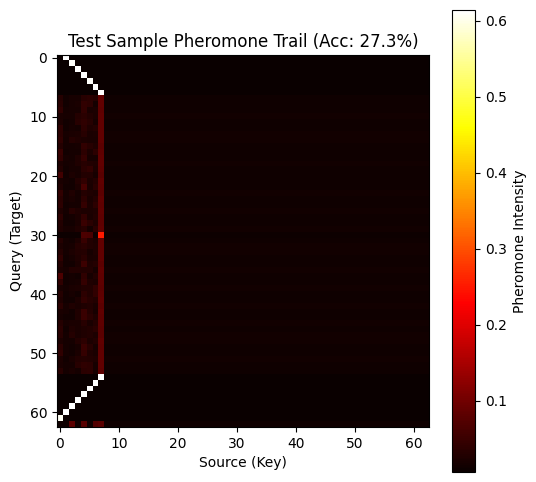

In [46]:
# Final evaluation for the precision tuning phase (K=8)
evaluate_model_accuracy(model)

--- Out-of-Sample Test ---
Sequence Length: 64
Vocabulary Size: 50
Mirroring Accuracy: 52.42%


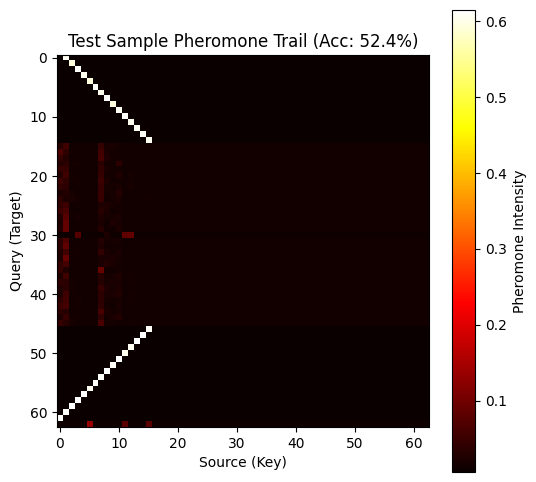

In [44]:
# Re-evaluating the model after extended training
evaluate_model_accuracy(model)

--- Out-of-Sample Test ---
Sequence Length: 64
Vocabulary Size: 50
Mirroring Accuracy: 52.39%


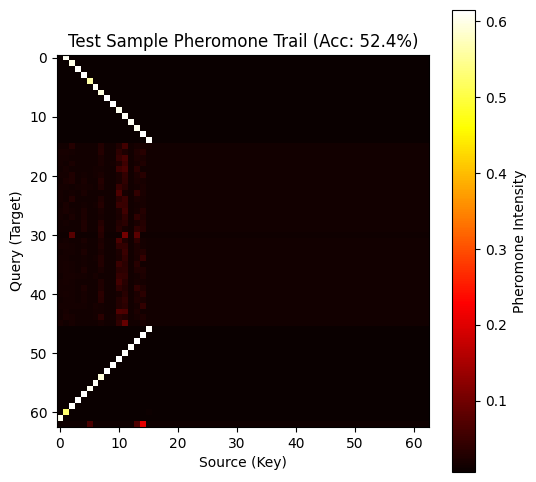

In [42]:
def evaluate_model_accuracy(model, num_samples=100):
    model.eval()
    with torch.no_grad():
        # Generate a fresh, larger batch for testing
        half = (BLOCK_SIZE // 2) - 1
        tokens = torch.randint(2, VOCAB_SIZE, (num_samples, half))
        sep = torch.full((num_samples, 1), 1)
        reversed_tokens = torch.flip(tokens, dims=[1])

        # x is the input, y is the target (shifted by 1)
        x = torch.cat([tokens, sep, reversed_tokens], dim=1).cuda()
        y = torch.cat([x[:, 1:], torch.zeros((num_samples, 1), dtype=torch.long, device='cuda')], dim=1)

        logits, tau = model(x)

        # Calculate accuracy only for the mirrored part (the second half)
        # The mirror starts after 'half' tokens + 1 separator
        predictions = torch.argmax(logits, dim=-1)

        # Mask to focus only on the mirrored tokens
        # We shift indices because y is shifted relative to x
        mirror_start_idx = half
        mirror_end_idx = BLOCK_SIZE - 2

        correct = (predictions[:, mirror_start_idx:mirror_end_idx] == y[:, mirror_start_idx:mirror_end_idx]).float()
        accuracy = correct.mean().item() * 100

        print(f'--- Out-of-Sample Test ---')
        print(f'Sequence Length: {BLOCK_SIZE}')
        print(f'Vocabulary Size: {VOCAB_SIZE}')
        print(f'Mirroring Accuracy: {accuracy:.2f}%')

        # Visualize one sample from the test batch
        plt.figure(figsize=(6,6))
        plt.imshow(tau[0].detach().cpu(), cmap='hot')
        plt.title(f"Test Sample Pheromone Trail (Acc: {accuracy:.1f}%)")
        plt.xlabel("Source (Key)")
        plt.ylabel("Query (Target)")
        plt.colorbar(label='Pheromone Intensity')
        plt.show()

evaluate_model_accuracy(model)

Precision Run | Step 2750/3000 | Loss: 2.3421


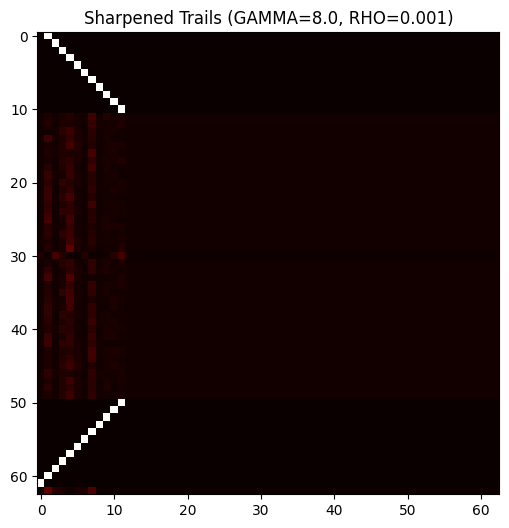

In [56]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from IPython.display import clear_output
import math

# ====================== CONFIG: HIGH PRECISION TUNING ======================
EMBED_DIM = 512
NUM_HEADS = 8
BLOCK_SIZE = 64
BATCH_SIZE = 32
MAX_ITERS = 3000
EVAL_INTERVAL = 250

# Pheromon params - SHARPENING
K = 12
GAMMA = 8.0     # Erhöht: Stärkerer Bias für Pfade
LOCAL_WINDOW = 0
RHO = 0.001     # Gesenkt: Minimale Verdunstung für maximale Stabilität

VOCAB_SIZE = 50
BASE_LR = 1e-4   # Niedrigerer LR für feine Justierung

def get_symmetry_batch():
    half = (BLOCK_SIZE // 2) - 1
    tokens = torch.randint(2, VOCAB_SIZE, (BATCH_SIZE, half))
    sep = torch.full((BATCH_SIZE, 1), 1)
    reversed_tokens = torch.flip(tokens, dims=[1])
    x = torch.cat([tokens, sep, reversed_tokens], dim=1)
    y = torch.cat([x[:, 1:], torch.zeros((BATCH_SIZE, 1), dtype=torch.long)], dim=1)
    return x.cuda(), y.cuda()

class SparsePheromonAttention(nn.Module):
    def __init__(self, embed_dim, num_heads):
        super().__init__()
        self.num_heads = num_heads
        self.head_dim = embed_dim // num_heads
        self.qkv = nn.Linear(embed_dim, 3 * embed_dim)
        self.proj = nn.Linear(embed_dim, embed_dim)

    def forward(self, x, tau):
        B, T, C = x.shape
        q, k, v = self.qkv(x).split(C, dim=-1)
        q = q.view(B, T, self.num_heads, self.head_dim).transpose(1, 2)
        k = k.view(B, T, self.num_heads, self.head_dim).transpose(1, 2)
        v = v.view(B, T, self.num_heads, self.head_dim).transpose(1, 2)
        logits = (q @ k.transpose(-2, -1)) * (self.head_dim ** -0.5)
        if tau is not None:
            logits = logits + (GAMMA * torch.log(tau + 1e-8)).unsqueeze(1)
        mask = torch.zeros((B, T, T), dtype=torch.bool, device=x.device)
        if tau is not None:
            topk = torch.topk(tau, min(K, T), dim=-1).indices
            mask.scatter_(-1, topk, True)
        logits = logits.masked_fill(~mask.unsqueeze(1), float('-inf'))
        attn_weights = F.softmax(logits, dim=-1)
        if tau is not None:
            with torch.no_grad():
                signal = attn_weights.mean(1)
                tau = (1 - RHO) * tau + torch.pow(torch.relu(signal - (1/T)), 2.0)
                tau = tau / (tau.sum(dim=-1, keepdim=True) + 1e-8)
        out = (attn_weights @ v).transpose(1, 2).reshape(B, T, C)
        return self.proj(out), tau

class SymmetryModel(nn.Module):
    def __init__(self, vocab_size=VOCAB_SIZE):
        super().__init__()
        self.emb = nn.Embedding(vocab_size, EMBED_DIM)
        self.pos = nn.Embedding(BLOCK_SIZE, EMBED_DIM)
        self.attn = SparsePheromonAttention(EMBED_DIM, NUM_HEADS)
        self.head = nn.Linear(EMBED_DIM, vocab_size)
    def forward(self, idx, tau=None):
        B, T = idx.shape
        x = self.emb(idx) + self.pos(torch.arange(T, device=idx.device))
        if tau is None: tau = torch.full((B, T, T), 0.01, device=idx.device)
        x, tau = self.attn(x, tau)
        return self.head(x), tau

model = SymmetryModel().cuda()
opt = torch.optim.AdamW(model.parameters(), lr=BASE_LR)

for step in range(MAX_ITERS):
    xb, yb = get_symmetry_batch()
    logits, tau = model(xb, None)
    loss = F.cross_entropy(logits.view(-1, VOCAB_SIZE), yb.view(-1))
    opt.zero_grad(); loss.backward(); opt.step()

    if step % EVAL_INTERVAL == 0:
        clear_output(wait=True)
        print(f"Precision Run | Step {step}/{MAX_ITERS} | Loss: {loss.item():.4f}")
        plt.figure(figsize=(6,6))
        plt.imshow(tau[0].detach().cpu(), cmap='hot')
        plt.title(f"Sharpened Trails (GAMMA={GAMMA}, RHO={RHO})")
        plt.show()